**I302 - Aprendizaje Automático y Aprendizaje Profundo**

<h1 style="text-align: center;"><strong>Trabajo Práctico 3: Redes Neuronales</strong></h1>

*Agustín A. Pereyra*

---

El presente trabajo tiene el objetivo de implementar y estudiar diferentes modelo de redes neuronales para clasificación multiclase a partir de un dataset de caracteres japoneses. Se implementan modelos básicos como modelos más avanzados con ciertas mejoras como optimización Adam, SGD, Regularización, etc. Al final se comparan estos modelos implementados *from scratch* con modelos definidos utilizando la librería de Machine Learning: PyTorch.

# **Análisis** y **Preprocesamiento** de Datos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import torch

from src.models import NN
from src.optimizers import GD, Momentum, AdaGrad, Adam, AdamW
from src.torch_models import TorchNN
from src.plots import show_images, show_class_samples, labels_distribution, training_summary, \
    batch_test_plot, optimizer_test_plot, lr_scheduling_test_plot, weight_decay_test_plot, \
    compare_final_models, show_noise_levels, robustness_plot, initialization_variance_plot
from src.model_selection import batch_test, optimizer_test, lr_scheduling_test, weight_decay_test,\
    grid_search, robustness_test, initialization_variance
from src.utils import indexed_path

plt.rcParams['font.family'] = 'Yu Gothic' # fuente con caracteres japoneses para visualizar labels reales
np.random.seed(36631)

In [ ]:
X = np.load('data/X_images.npy')
y = np.load('data/y_images.npy')

El dataset de este trabajo parece corresponder a un subconjunto de [**Kuzushiji-MNIST**, **K49**](https://github.com/rois-codh/kmnist) o alguno similar en el que se tienen 5000 imágenes de 28x28 píxeles de escritos de caracteres japoneses. Entre ellas encontramos 49 clases diferentes a identificar con nuestros modelos. 

> [**Disclaimer**] Los labels (en japonés) asignados en este trabajo fueron tomados del [dataset original](https://arxiv.org/abs/1812.01718), por lo que es posible que haya alguna confusión con alguno.

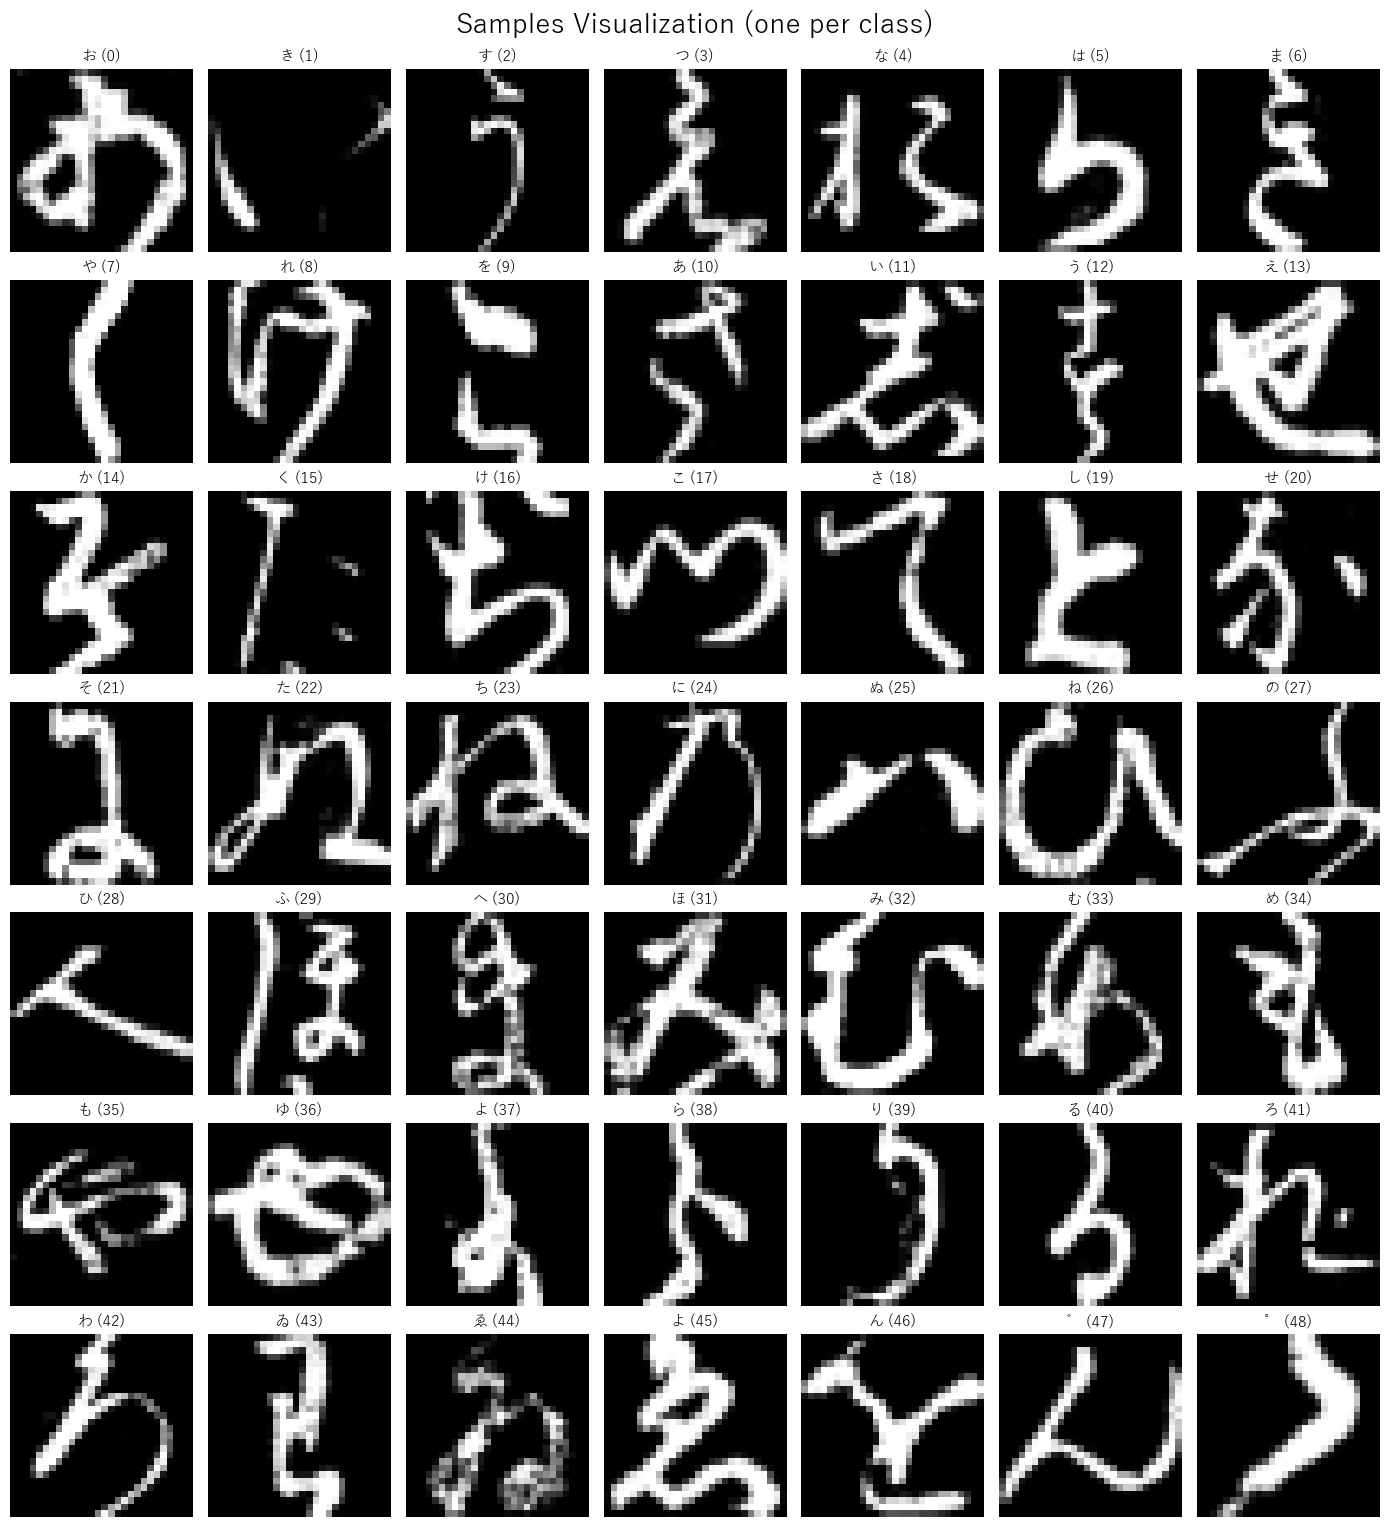

In [ ]:
show_images(X, y)

Al observar varias muestras de una misma clase veremos que en general los trazos para cada caracter difieren significativamente, como suele pasar en estos tipos de dataset de la familia MNIST.

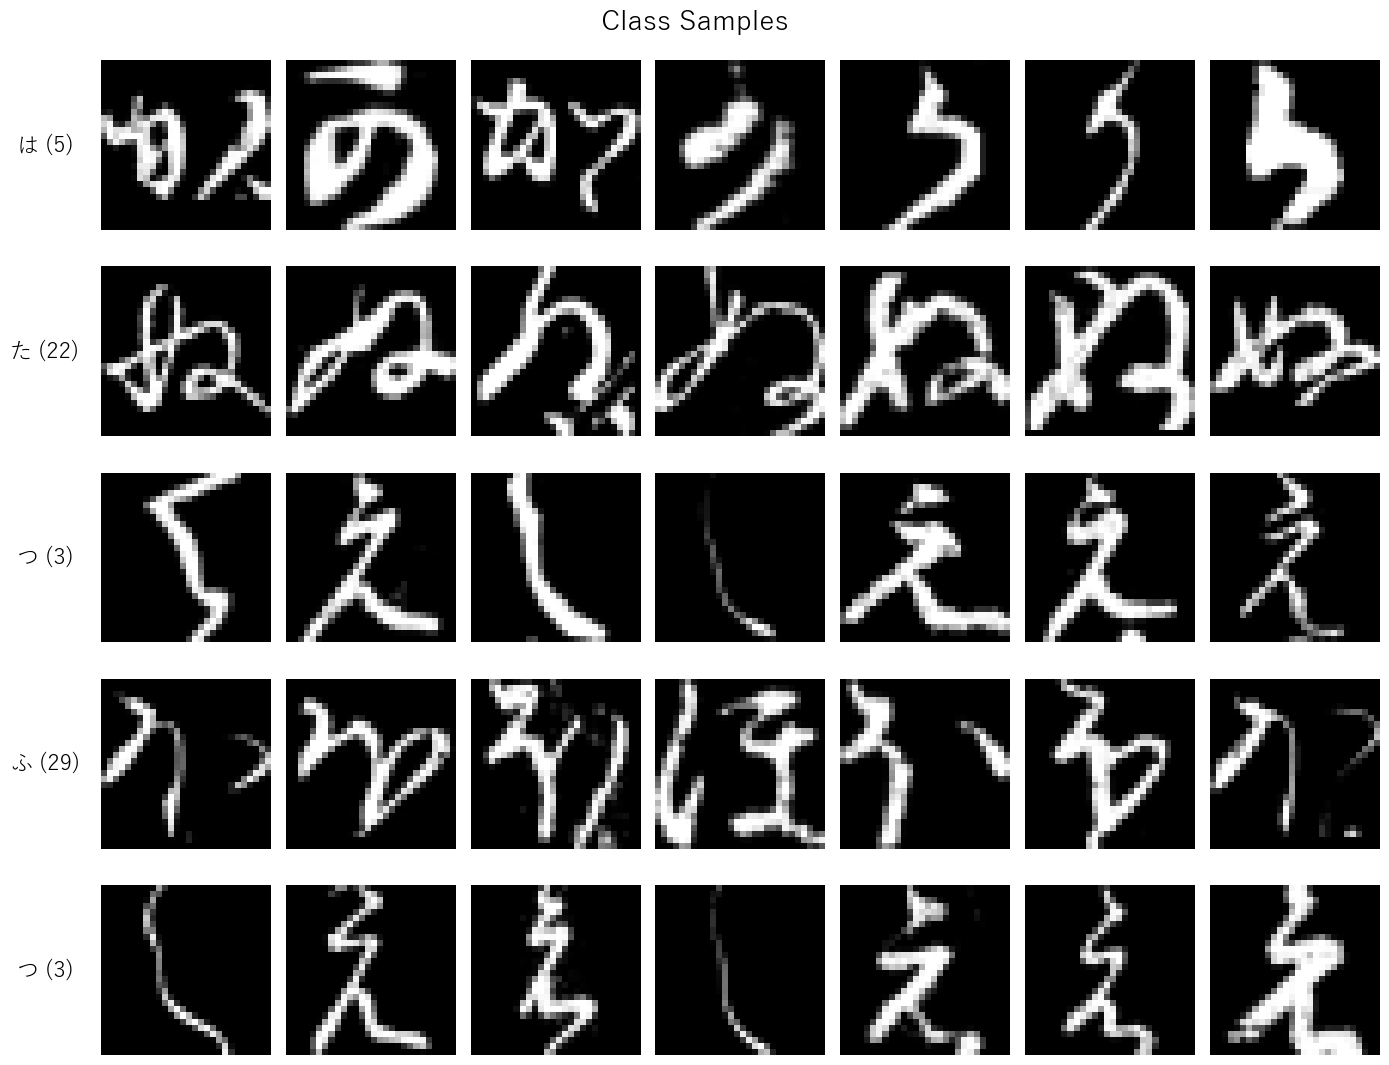

In [ ]:
show_class_samples(X, y, labels=np.random.randint(low=0, high=49, size=5).tolist(), n=7)

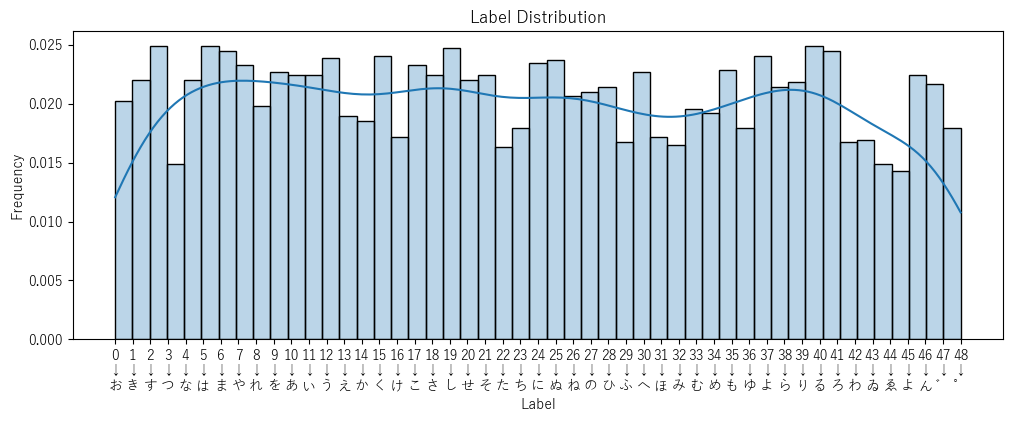

In [ ]:
labels_distribution(y)

### **Normalización**

Los pixeles de las imágenes se dividirán por 255 de manera que todos los valores quede acotados en $[0,1]$ y así mejorar la estabilidad numérica de los próximos modelos.

In [ ]:
X = X / 255

### **División** del Dataset

Para estas primeras secciones utilizaremos exclusivamente un 80% del dataset que corresponde al *dev set*, del cual utilizaremos un 80% del mismo para entrenar (*train set*) y un 20% para evaluar (*val set*). Luego al final del trabajo se utilizará este 80% del dataset para entrenar los modelos finales y se realizarán la última comparación evaluando sobre el 20% del dataset correspondiente al *test set*.

In [ ]:
idx = np.random.permutation(len(X))

test_size = int(0.2 * len(X)) # 20% test
dev_idx, test_idx = idx[test_size:], idx[:test_size]

X_dev, y_dev = X[dev_idx],  y[dev_idx]
X_test, y_test = X[test_idx], y[test_idx]

val_size = int(0.2 * len(X_dev)) # 20% del dev para val
dev_idx = np.random.permutation(len(X_dev))
train_idx, val_idx = dev_idx[val_size:], dev_idx[:val_size]

X_train, y_train = X_dev[train_idx],  y_dev[train_idx]
X_val, y_val = X_dev[val_idx], y_dev[val_idx]

In [ ]:
input_size = X[0].size
output_size = np.unique(y).size

# Implementación y Entrenamiento de una **Red Neuronal Básica**

## **Modelo** $\boldsymbol{M_0}$

El primer modelo implementado de un Multi-Layer Perceptron (MLP) básico que utiliza Gradient Descent Estándar y 2 capas ocultas con función de activación ReLU y una capa final de salida Softmax.

$$
\text{ReLU}(x) = \max(0,x)
$$

A continuación se detallan particularidades del modelo, como la función de costo y el resultado de la combinación de esta función de costo y la capa de salida Softmax sobre el algoritmo de **back-propagation**.

### **Función de Costo**: *Cross-Entropy*

Para un problema de clasificación multiclase con $K$ clases, la función de costo utilizada es la **cross-entropy**, que mide la disimilitud entre la distribución predicha $\mathbf{z}^{(L)}=\hat{\mathbf{y}}$ y la distribución verdadera $\mathbf{y}$ (one-hot):

$$
\mathcal{L}(\mathbf{y}, \hat{\mathbf{y}}) = -\sum_{k=1}^{K} y_k \log \hat{y}_k
$$

Como $\mathbf{y}$ es one-hot (solo una clase es 1, el resto son 0), la sumatoria colapsa a un único término:

$$
\mathcal{L} = -\log \hat{y}_{c}^{}
$$

donde $c$ es la clase verdadera. Para un batch de $m$ ejemplos, promediamos:

$$
\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log \hat{y}_k^{(i)}
$$

La función de costo es mínima cuando el modelo asigna probabilidad 1 a la clase correcta, y crece hacia infinito cuando le asigna probabilidad 0.

### **Backpropagation en la Capa de Salida**: *Softmax + Cross-Entropy*

Para una red neuronal de $L$ capas con **Softmax** como función de activación de la capa de salida y **entropía cruzada** como función de pérdida, el error de propagación en esta última capa $\boldsymbol{\delta}^{(L)} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}^{(L)}}$, es decir el gradiente de la pérdida respecto a la pre-activación de la última capa, se obtiene aplicando la regla de la cadena:

$$
\boldsymbol{\delta}_k^{(L)} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}_k^{(L)}} = \sum_{j} \frac{\partial \mathcal{L}}{\partial \mathbf{z}_j^{(L)}} \cdot \frac{\partial \mathbf{z}_j^{(L)}}{\partial \mathbf{a}_k^{(L)}}
$$

**Gradiente de la cross-entropy respecto a la activación de salida:**

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{z}_j^{(L)}} = -\frac{y_j}{\mathbf{z}_j^{(L)}}
$$

**Jacobiano de la Softmax** (función vectorial $\mathbb{R}^K \to \mathbb{R}^K$, no escalar):

$$
\frac{\partial \mathbf{z}_j^{(L)}}{\partial \mathbf{a}_k^{(L)}} = \mathbf{z}_j^{(L)}\left(\mathbb{I}[j = k] - \mathbf{z}_k^{(L)}\right)
$$

donde $\mathbb{I}[j = k]$ es la función indicadora. Sustituyendo ambas expresiones:

$$
\boldsymbol{\delta}_k^{(L)} = \sum_{j} \left(-\frac{y_j}{\mathbf{z}_j^{(L)}}\right) \mathbf{z}_j^{(L)}\left(\mathbb{I}[j = k] - \mathbf{z}_k^{(L)}\right) = -\sum_{j} y_j \left(\mathbb{I}[j = k] - \mathbf{z}_k^{(L)}\right)
$$

Expandiendo y usando que $\sum_j y_j = 1$ (one-hot):

$$
\boldsymbol{\delta}_k^{(L)} = -y_k + \mathbf{z}_k^{(L)} \underbrace{\sum_{j} y_j}_{=1} = \mathbf{z}_k^{(L)} - y_k
$$

En forma vectorial, el resultado es notablemente simple:

$$
\boldsymbol{\delta}^{(L)} = \mathbf{z}^{(L)} - \mathbf{y} = \hat{\mathbf{y}} - \mathbf{y}
$$

Esta simplificación es la razón principal por la que la combinación softmax + cross-entropy es estándar en clasificación multiclase: el Jacobiano completo de la softmax (una matriz $K \times K$) se cancela algebraicamente y el gradiente resultante es solo la diferencia entre la predicción y el target. Esto es numéricamente estable y computacionalmente eficiente.

### **Inicialización de Parámetros**: *He initialization*

Para una red neuronal es fundamental el rol de la inicialización de pesos, puesto que en caso de no considerarla podríamos llevar a que esta no se entrena en lo absoluto a pesar de ejecutar el algoritmo entero de entrenamiento por el **problema de simetría**. Lo esencial es que los pesos se inicialicen de forma aleatoria y con valores no lejanos al 0 para no provocar una explosión de gradiente dentro de **backpropagation**. 

En esta ocasión utilizaremos la inicialización llamada **He initialization**, una variante de la típica **Glorot/Xavier initialization** en la que la distribución normal utilizada para samplear cada parámetro $(w_{ij}^{(\ell)}\sim \mathcal{N}(0,\sigma^2))$ se define a partir de la cantidad del *fan in* (número de conexiones entrantes)

$$
\sigma^2 = \frac{2}{n_\text{in}}
$$

Como indican las bibliografías de la materia, el método de inicialización **depende de las funciones de activación** de la red, por esto se seleccionó esta inicialización que es la recomendada para utilizar en redes con activaciones ReLU y sus variantes.

In [ ]:
M0_layers = [(128, 'relu'), (64, 'relu')]
M0_fit_params = {'epochs' : 400}
M0 = NN(input_size, output_size, layers=M0_layers, optimizer=GD)
M0_train_hist = M0.fit(X_train, y_train, X_val, y_val, **M0_fit_params)

Training: 100%|██████████| 400/400 [00:29<00:00, 13.77epoch/s, train_loss=0.7893, val_loss=1.7256]

[completed] — epoch: 400 | train_loss: 0.7893 | val_loss: 1.7256 | time: 29.1s


Una vez entrenado este primer modelo podemos analizar su desempeño tanto calculando métricas como **accuracy** y **f1-score** macro como observando la matriz de confusión generada a partir de las predicciones del modelo. En la siguiente figura vemos un resumen del modelo entrenado, tanto para el conjunto de entrenamiento como para el de validación. 

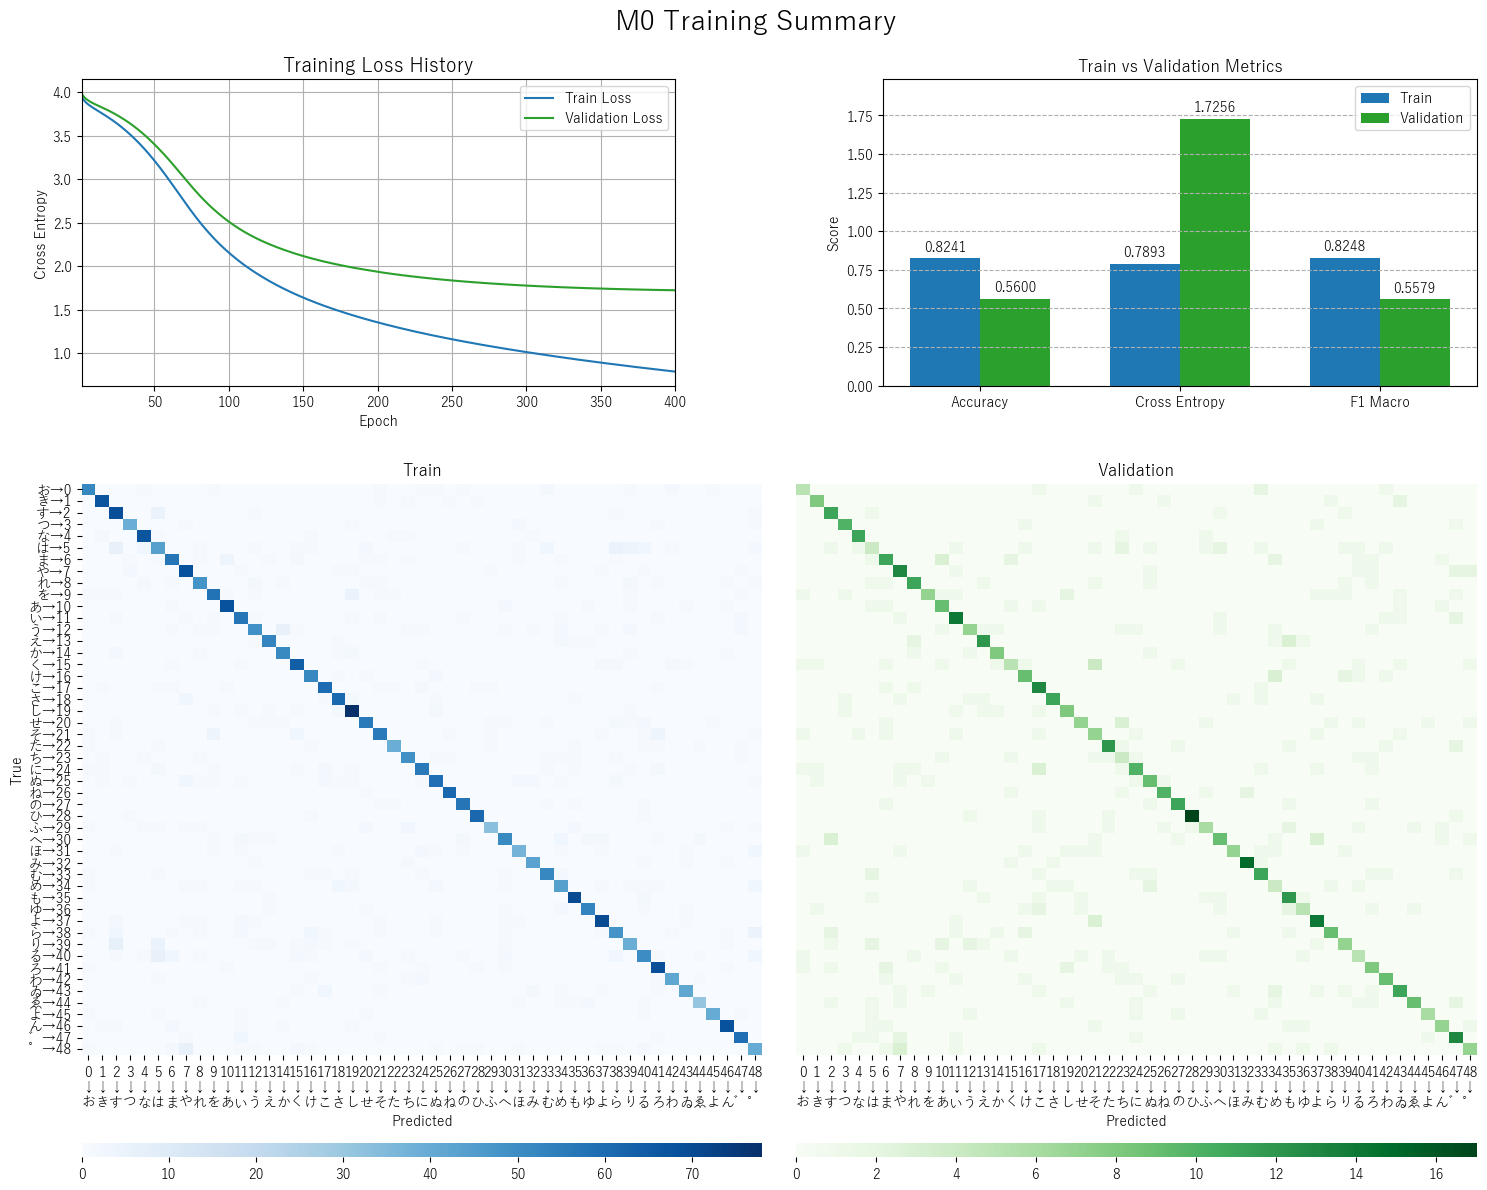

In [ ]:
training_summary(M0, M0_train_hist, X_train, y_train, X_val, y_val, title='M0 Training Summary')

El modelo es entrenado por 400 épocas no por casualidad, sino que después de algunas pruebas es en promedio el punto de inflexión del costo en validación, por lo que es aproximadamente el punto óptimo de entrenamiento de $M_0$. Este modelo al ser tan simple no se llega a ajustarse por completo a los datos de entrenamiento, aunque tampoco alcanza a generalizar del todo obteniendo una F1$\approx 0.5579$ y una desalentadora Accuracy alrededor de $0.56$.   

Veremos que al volver los modelos más complejos estos se adecuarán mucho más rápido al conjunto de entrenamiento, lo que en algunos casos llevará a un overfitting total (accuracy en train de 1.0), y aún así un mejor desempeño que este primer modelo. Además con algunas técnicas de regularización este overfitting se puede combatir en alguna medida.

# Implementación y Entrenamiento de una **Red Neuronal Avanzada**

En esta sección se realizan ciertas mejoras al modelo de la Red Neuronal. Se utilizan las siguientes mejoras y opciones de regularización en el entrenamiento del modelo. 

Se analizará el efecto marginal de cada uno de estas mejoras sobre los modelos resultantes respecto al modelo básico $M_0$ dejando todos los hiperparámetros del modelo fijos:

### **Entrenamiento**: *Mini-batch SGD*

El gradiente descendente estándar (*batch GD*) computa el gradiente de la función de costo sobre **todo** el conjunto de entrenamiento en cada iteración:

$$
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \nabla_{\boldsymbol{\theta}} \mathcal{L}(\boldsymbol{\theta}_t)
$$

Si bien este gradiente es exacto, resulta prohibitivamente costoso para datasets grandes. El **Descenso de Gradiente Estocástico** (SGD) usa un único ejemplo por iteración, lo que introduce mucha varianza. El balance entre ambos extremos es el **mini-batch SGD**: en cada iteración se selecciona aleatoriamente un subconjunto $\mathcal{B}_t \subset \{1, \ldots, N\}$ de tamaño $|\mathcal{B}| = B$ y se computa el gradiente solo sobre esos ejemplos:

$$
\nabla_{\boldsymbol{\theta}} \mathcal{L} \approx \frac{1}{B} \sum_{i \in \mathcal{B}_t} \nabla_{\boldsymbol{\theta}} \ell(\boldsymbol{\theta};\, \mathbf{x}^{(i)}, \mathbf{y}^{(i)})
$$

Este estimador del gradiente es **insesgado**, ya que $\mathbb{E}_{\mathcal{B}}[\hat{g}] = \nabla \mathcal{L}$, y su varianza decrece con $B$. El ruido introducido por el mini-batch actúa como un regularizador implícito que puede ayudar a escapar de mínimos locales pobres.

En la práctica, al comienzo de cada época se **permuta aleatoriamente** el dataset y luego se recorre en bloques de tamaño $B$, de modo que todos los ejemplos sean vistos exactamente una vez por época. Una **época** queda definida como un recorrido completo sobre el conjunto de entrenamiento, independientemente del tamaño del batch. La regla de actualización en el paso $t$ es:

$$
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \cdot \frac{1}{B} \sum_{i \in \mathcal{B}_t} \nabla_{\boldsymbol{\theta}} \ell_i(\boldsymbol{\theta}_t)
$$

In [ ]:
batch_results = batch_test(M0, X_train, y_train, X_val, y_val, 
                           batch_sizes=[1, 64, 128, 512, 1024, 2048, None])

batch_size=None: 100%|██████████████████| 7/7 [09:54<00:00, 84.94s/batch, val_loss=1.7319]


<a id="loss_ceil"></a>
En esta prueba vemos la evolución de la función de costo tanto en el conjunto de entrenamiento como en el de validación a lo largo de 300 épocas de entrenamiento para el modelo $M_0$ con diferentes batch_sizes de SGD.

En el caso de SGD puro (*batch_size=1*) el error en ambos conjuntos es muy elevado respecto a los demás casos debido al alto learning rate $\eta$ de $M_0$. La alta varianza de calcular $\nabla_w \mathcal{L}$ con solo una muestra combinado con un gran $\eta$ da como resultado una loss oscilante y no-convergente. Además ambas losses se mantienen asintóticamente en el **techo de la loss**. ¿Cómo uno conoce esto último? Pues la entropía cruzada de $n$ clases con probabilidad uniforme $(\hat{y}_c=\frac{1}{n} \; \forall c)$:

$$
\mathcal{L} = -\log(\hat{y}_c) = -\log\left(\frac{1}{n}\right) = \log(n)
$$

entonces para nuestro caso con 49 clases, $\log(49)\approx 3.89$, dando a entender que en nuestro caso $M_0$ con un tamaño de mini-batch de 1 no aprende en lo absoluto y se comporta como un modelo aleatorio. 

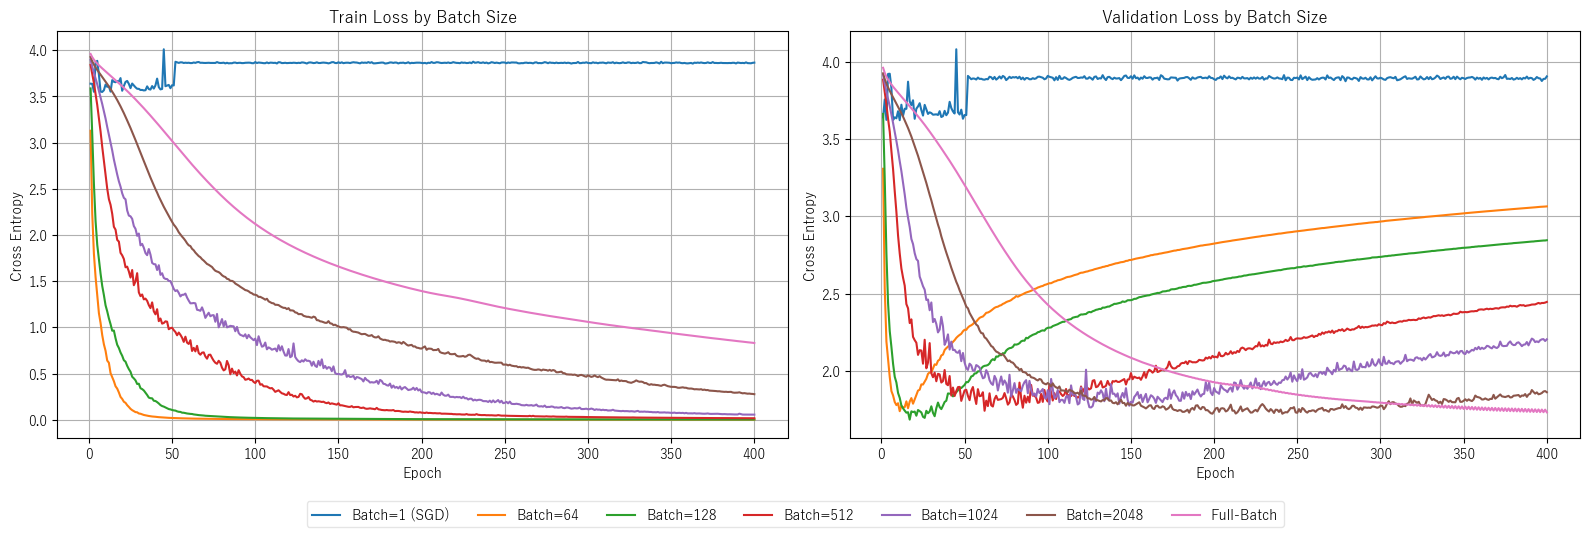

In [ ]:
batch_test_plot(batch_results)

Luego los casos interesantes son con *batch_size* a partir de 64, en donde para poca cantidad de épocas se llega a los mínimos valores de ambas losses. En particular para `Batch=64` la loss en validation llega a su mínimo alrededor de la época 20, siendo que el caso de Full-Batch ni siquiera alcanza este valor mínimo para la época 300, mini-batch contiene cierto ruido. Este ruido o varianza en la loss se observa para todos los casos de mini-batch, y es el precio a pagar de entrenar con pedazos del dataset en lugar del dataset entero. Esta se puede reducir tanto reduciendo el learning-rate fijo como utilizando optimizadores adaptativos o con momentum.

### **Optimizador**: *Adam*

El gradiente descendente estándar aplica la misma tasa de aprendizaje $\eta$ a todos los parámetros. [**Adam**](https://arxiv.org/abs/1412.6980) (*Adaptive Moment Estimation*, Kingma & Ba, 2014) mantiene estimaciones adaptativas de los dos primeros momentos del gradiente para cada parámetro, logrando pasos efectivos distintos por dimensión.

Define $\mathbf{g}_t = \nabla_{\boldsymbol{\theta}} \mathcal{L}_t$ el gradiente en el paso $t$. Adam mantiene:

- $\mathbf{m}_t$: estimación del **primer momento** (media del gradiente)
- $\mathbf{v}_t$: estimación del **segundo momento** "crudo" (varianza no centrada del gradiente)

Calculándolos tal que:

$$
\mathbf{m}_t = \beta_1\, \mathbf{m}_{t-1} + (1 - \beta_1)\, \mathbf{g}_t
$$

$$
\mathbf{v}_t = \beta_2\, \mathbf{v}_{t-1} + (1 - \beta_2)\, \mathbf{g}_t \odot \mathbf{g}_t
$$

donde $\beta_1, \beta_2 \in [0,1)$ son hiperparámetros que controlan el ratio de decaimiento exponencial de los momentos.

Como $\mathbf{m}_0 = \mathbf{v}_0 = \mathbf{0}$, ambas estimaciones están sesgadas hacia cero al comienzo del entrenamiento. Se corrige dividiendo por el factor de sesgo correspondiente:

$$
\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1 - \beta_1^t}, \qquad \hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_2^t}
$$

La regla de actualización de los parámetros es entonces:

$$
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta\, \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon}
$$

donde $\epsilon > 0$ es un término de estabilidad numérica que evita divisiones por cero. Los hiperparámetros recomendados por los autores del algoritmo son $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$.

In [ ]:
optimizers = [GD, Momentum, AdaGrad, Adam]
optimizers_parameters = [{'lr':0.1}, {'lr':0.1}, {'lr':1e-2}, {'lr':[1e-2,5e-3]}]
optimizer_results = optimizer_test(M0, X_train, y_train, X_val, y_val, 
                                   optimizers=optimizers, parameters=optimizers_parameters)

Adam(lr=0.005): 100%|███████████████████████████████████████| 5/5 [02:09<00:00, 25.86s/model, val_loss=3.3016]


En el gráfico se tiene una situación similar a la subsección anterior, pero donde cada modelo varía únicamente en el optimizador utilizado y en el learning rate de estos. En un primer vistazo lo que se destaca es la rápida convergencia del modelo con Adam de $\eta=0.01$, dando alrededor de la época 25 el mínimo del costo en validación. Este a su vez es el primero en comenzar overfittear debido al alto learning rate, aunque es notable el buen resultado que alcanza en una cantidad de épocas tan reducido. 

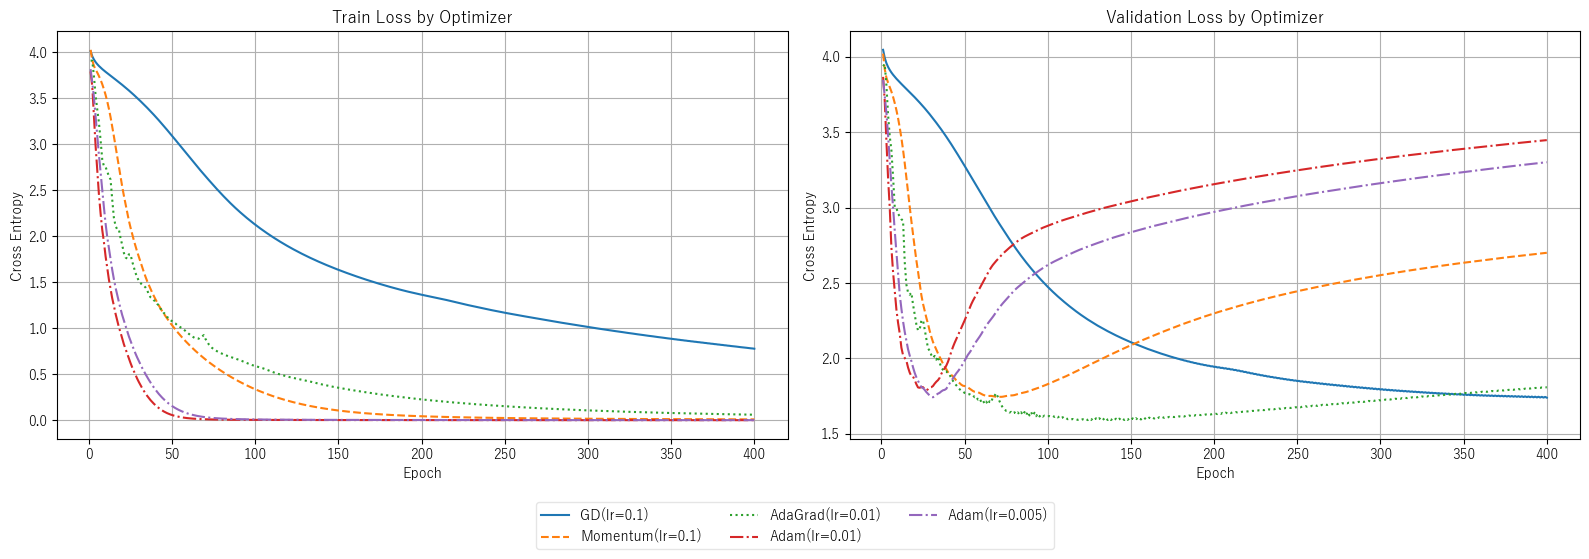

In [ ]:
optimizer_test_plot(optimizer_results)

En general todos los modelos con optimizadores superiores al *gradient descent* estándar llegan a un óptimo de loss en validación antes de la época 100, y en algunos casos hasta llegan a valores a los que este estándar no alcanza ni para nuestro límite de épocas (400). Además aunque AdaGrad pareciera ser más eficiente que Adam porque alcanza menores niveles de costo en validación con pocos signos de overfitting (al menos entre las épocas 100 y 150), este presenta una notable varianza o ruido que Adam elimina gracias a la "memoria" incorporada por el concepto de **momentum** y además este llega a valores relativamente cercanos y en muchas menos épocas. 

En deep learning alcanzar un buen entrenamiento del modelo en pocas épocas es importante dado que los conjuntos de datos suelen ser inmensos, por lo que requerimos de una rápida convergencia a menores épocas (dado que una época representa un paso del dataset completo por la red). A pesar de que el dataset de este trabajo no tiene la gran cardinalidad que suelen tener los conjuntos en el campo del deep learning, buscamos tanto optimalidad del modelo como efectividad en cuanto a velocidad de convergencia.

In [ ]:
beta1 = [0.85, 0.9, 0.95]
beta2 = [0.99, 0.999, 0.9999]
adam_parameters = [{'beta1': beta1, 'beta2': beta2}]
adam_results = optimizer_test(M0, X_train, y_train, X_val, y_val, 
                                   optimizers=[Adam], parameters=adam_parameters)

Adam(beta1=0.95, beta2=0.9999): 100%|███████████████████████| 9/9 [03:54<00:00, 26.05s/model, val_loss=2.4353]


En el diagrama de abajo están representados los efectos de variar los dos parámetros de decaimiento exponencial de momentos $(\beta_1, \beta_2)$ de Adam para un learning-rate común $(\eta=0.001)$. Pequeñas variaciones que permiten al algoritmo obtener costos mínimos en validación en diferente épocas, aunque en todos los casos el camino es el mismo y el óptimo se encuentra antes de la época número 100. 

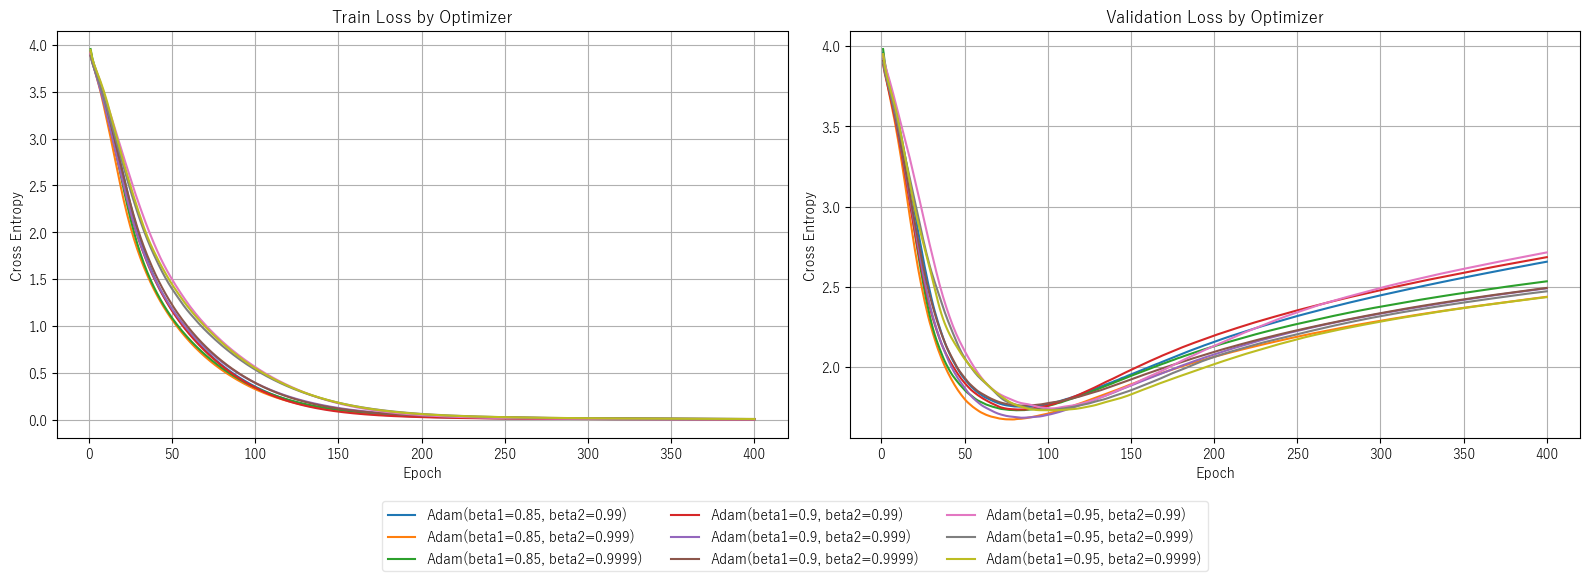

In [ ]:
optimizer_test_plot(adam_results)

### **Learning Rate Scheduling**

Mantener la tasa de aprendizaje $\eta$ fija durante todo el entrenamiento es subóptimo: un $\eta$ grande permite descensos rápidos al principio pero impide converger con precisión, mientras que un $\eta$ pequeño converge con lentitud. El **learning rate scheduling** consiste en reducir $\eta$ a medida que avanza el entrenamiento. Consideramos dos estrategias:

**Decaimiento Lineal (con saturación)** (*linear decay with saturation*)

La tasa disminuye linealmente desde $\eta_0$ hasta un mínimo $\eta_{\min}$ en la época $T$, y se mantiene constante a partir de allí:

$$
\eta_t = \eta_0 \cdot \max\!\left(1 - \frac{t}{T},\; \frac{\eta_{\min}}{\eta_0}\right)
$$

El piso $\eta_{\min} > 0$ es la "saturación": evita que la tasa caiga a cero y que el entrenamiento se detenga por completo antes de converger.

**Decaimiento Exponencial** (*exponential decay*)

La tasa se multiplica por un factor $\gamma \in (0, 1)$ en cada época:

$$
\eta_t = \eta_0 \cdot \gamma^t
$$

El decaimiento es rápido al principio y se ralentiza asintóticamente. A diferencia del lineal, nunca alcanza cero exactamente. (notar que cuando $\gamma=1$ es equivalente a un learning rate constante)

Ambos esquemas buscan el mismo efecto: **dar pasos grandes al inicio para explorar el espacio de parámetros y pasos pequeños al final para refinar la solución**. En la práctica, con Adam el scheduling es menos crítico porque el optimizador ya adapta el paso efectivo por parámetro; sin embargo, combinarlo con un decaimiento de $\eta$ global puede mejorar la convergencia final.

In [ ]:
gammas=[0.999, 0.9975, 0.995, 0.99, 0.98, 0.97]
mins=[3e-1, 2e-1, 1.5e-1, 1e-1, 1e-2, 1e-3, 1e-4]
scheduling_results = lr_scheduling_test(M0, X_train, y_train, X_val, y_val, lr_mins=mins,gammas=gammas)

exp(gamma=0.97): 100%|██████████████████████████| 14/14 [05:57<00:00, 25.54s/model, val_loss=3.4876]


A continuación vemos el comportamiento de $M_0$ al agregar uno de las dos alternativas de scheduling para diferentes valores de sus parámetros ($\gamma$ en el caso de exponencial y $\eta_{\min}$ en el de lineal con saturación). En este modelo en particular vemos disminuir de forma exponencial a la tasa de aprendizaje no mejora en lo absoluto al modelo, obteniendo siempre peores y más lentas valores de la función de pérdida (en validación). Mientras tanto para el caso de scheduling lineal para los casos de $\eta_{\min}>0.1$ si se consiguen mejores resultados respecto al modelo de $\eta$ constante, aunque a costo de alta varianza en la loss.

Aunque por este gráfico podríamos deducir que un scheduling lineal con $\eta_{\min} \approx 0.15$ es el óptimo, es de importancia mencionar que se realizaron variadas pruebas sobre los próximo modelos (implementando el algoritmo de grid-search) y no se encontró una diferencia significativa entre las 2 alternativas, aunque la exponencial si tuvo apenas mejores resultados. Es únicamente por esto que nos restringimos a utilizar este para los próximos modelos.

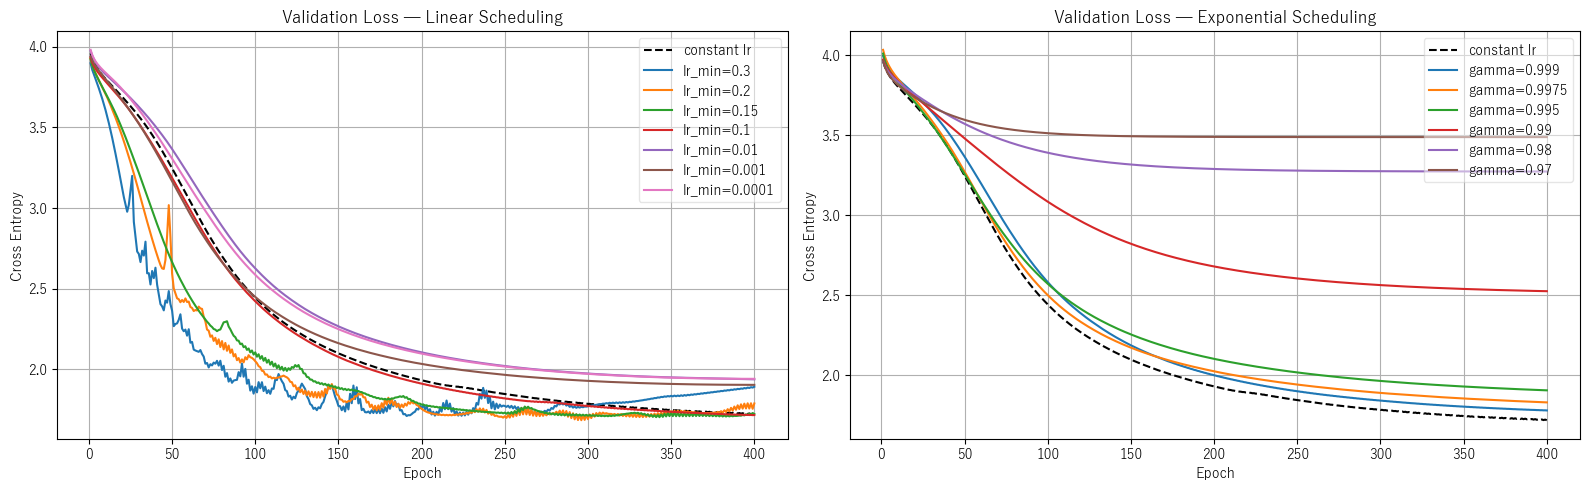

In [ ]:
constant_results, linear_results, exponential_results = scheduling_results
lr_scheduling_test_plot(constant_results, linear_results, exponential_results)

### **Regularización:** *Early Stopping + Weight Decay*

Con el fin de evitar el sobre-ajuste de la red, se implementaron las siguiente técnicas de regularización de redes neuronales:

**Early Stopping**: El algoritmo de entrenamiento en lugar de realizar un número fijo de epocas, puede decidir el frenar antes de llegar a al número máximo de épocas con el criterio de cierta cantidad de épocas sin mejora de la función de pérdida sobre el set de validación. A esta cantidad se le llama **paciencia**.

**Weight Decay (AdamW)**: La regularización $L_2$ clásica agrega un término de penalización a la función de costo:

$$
\mathcal{L}_{\text{p}}(\boldsymbol{\theta}) = \mathcal{L}(\boldsymbol{\theta}) + \frac{\lambda}{2} \|\boldsymbol{\theta}\|^2
$$

En el gradiente descendente estándar esto produce el efecto de *shrinkage* $(1-\eta\lambda)$ sobre los pesos, de ahí el nombre *weight decay*. Sin embargo, **combinado con Adam esto no funciona correctamente**: el optimizador escala cada componente del gradiente por $1/\sqrt{\hat{\mathbf{v}}_t}$, de modo que el término de regularización $\lambda\,\boldsymbol{\theta}$ también queda escalado de forma no uniforme por dimensión, distorsionando el efecto de la penalización.

La solución es el **weight decay desacoplado** (*decoupled weight decay*, AdamW): en lugar de incluir la penalización en el gradiente, se aplica directamente sobre los parámetros **después** del paso de Adam, de forma independiente al optimizador:

$$
\boldsymbol{\theta}_{t+1} = (1 - \eta\lambda)\,\boldsymbol{\theta}_t - \eta\,\frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon}
$$

Así el decaimiento $(1-\eta\lambda)$ es uniforme para todos los parámetros, independientemente de la magnitud de sus gradientes históricos. Esto restaura la interpretación original del weight decay como una penalización sobre la norma de los pesos, sin interferir con la adaptatividad de Adam.

In [ ]:
optimizer_info = {GD : {'lr':0.1}, AdamW : {'lr':0.01}}
weight_decay_results = weight_decay_test(M0, X_train, y_train, X_val, y_val, 
                  optimizer_info=optimizer_info, weight_decays=[0.0, 1e-2, 1e-1, 2e-1, 5e-1])

AdamW(wd=0.5): 100%|██████████████████████████████████████| 10/10 [04:18<00:00, 25.80s/model, val_loss=2.2229]


Para comparar la diferencia de rendimiento del modelo con y sin regularización es de interés dividirlo entre los modelos con gradient-descent común y Adam(W) dado que como notamos anteriormente Adam lleva a una convergencia mucho más veloz, y entonces:

1. Con *weight-decay* Adam tendrá un tanto más dificil el sobre-ajuste intenso, por lo que manteniendo una rápida convergencia el modelo tendrá mayor capacidad de generalización   
2. Dado esta rápida convergencia es de suma importancia interrumpir el entrenamiento en cuanto el costo sobre el conjunto de validación aumente. Como vimos, Adam a una cantidad alta de épocas diverge en validación dado que ajuste por demás a los datos de entrenamiento.

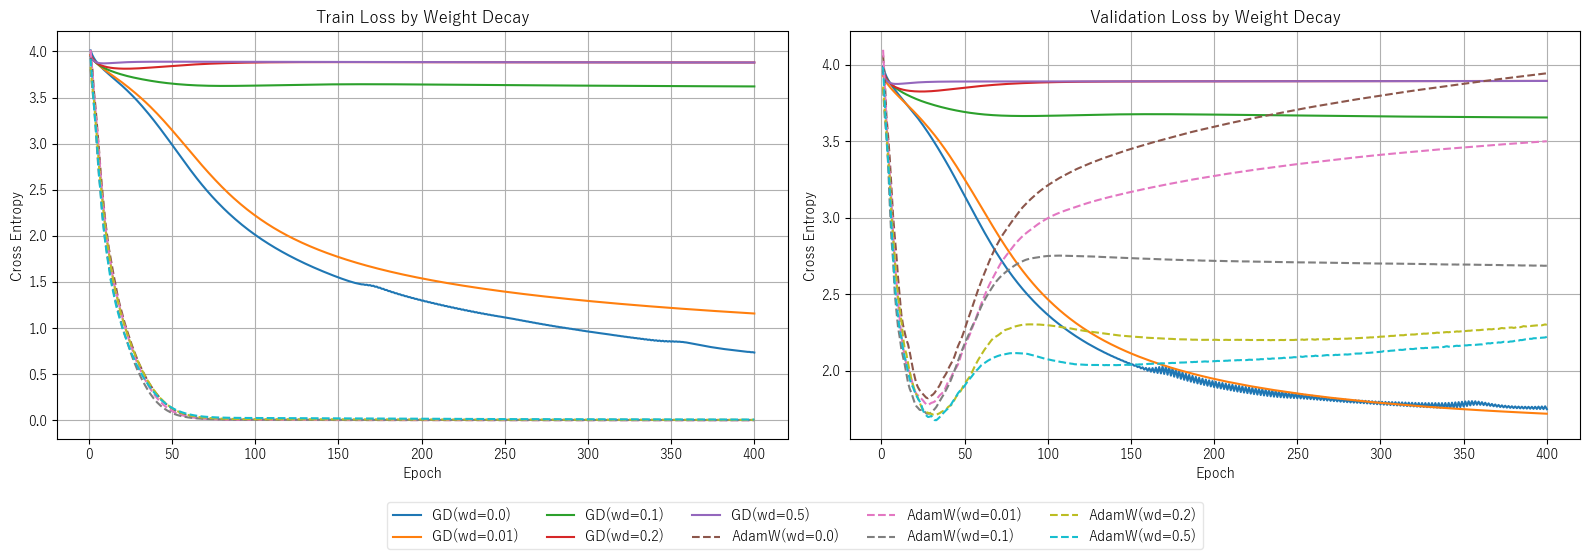

In [ ]:
weight_decay_test_plot(weight_decay_results)

## **Modelo** $\boldsymbol{M_1}$

Como vimos cada una de las mejoras incluidas al modelo de la red neuronal implica nuevas hiperparámetros, por lo que es necesario encontrar una combinación de estos parámetros óptima. Además, buscaremos una estructura de red (capas + neuronas por capa) que también optimice la función de costo. Es por esto que realizamos un **Grid Search** que evalua la función de costo en el conjunto de validación para cada uno de los modelos resultantes de las distintas combianaciones posibles para las estructuras propuestas y los diferentes valores para cada uno de los hiperparámetros:

In [ ]:
M1_param_grid = {
    'layers': [
        [(128, 'relu')],
        [(256, 'relu')],
        [(512, 'relu')],
        [(1024, 'relu')],
        [(128, 'relu'), (64, 'relu')],
        [(256, 'relu'), (64, 'relu')],
        [(512, 'relu'), (128, 'relu')],
        [(1024, 'relu'), (128, 'relu')]
    ],
    'gamma' : [0.975, 0.96, 0.95, 0.9],
    'batch_size' : [64, 256, 512],
}
M1_optim_param_grid =  {'lr' : [1e-2, 1e-1], 'weight_decay': [0.25, 0.2, 0.15, 0.1]}

M1_fit_params = {'epochs' : 100,  'patience' : 10, 'lr_schedule' : 'exponential'}

M1_gs = grid_search(
    X_train, y_train, X_val, y_val,
    param_grid=M1_param_grid,
    optimizer_param_grid=M1_optim_param_grid,
    fit_params=M1_fit_params,
    model_class=NN,
    optimizer_class=AdamW
)

GRID SEARCH [NN / AdamW] — 768 models [layers(8) x gamma(4) x batch_size(3) x lr(2) x weight_decay(4)]


[1024→128]: 100%|██████████| 768/768 [3:14:22<00:00, 15.19s/model, best=1.1710, val_loss=2.6521]   


In [ ]:
M1_gs.to_csv(indexed_path('results/grid-search-M1.csv'))

In [ ]:
M1_gs.drop(columns=['layers_config']).head(15)

,layers,gamma,batch_size,lr,weight_decay,val_loss,val_f1_macro,epochs_trained
1,[1024],0.900,64,0.01,0.20,1.1710,0.7122,25
2,[1024],0.950,64,0.01,0.25,1.1954,0.7163,24
3,[512],0.950,64,0.01,0.20,1.2102,0.7144,23
4,[512],0.900,64,0.01,0.25,1.2158,0.6944,26
5,[512],0.950,64,0.01,0.25,1.2177,0.7111,32
6,[1024],0.900,64,0.01,0.25,1.2255,0.7033,27
7,[1024],0.900,64,0.01,0.15,1.2280,0.7083,39
8,[1024],0.950,64,0.01,0.20,1.2333,0.7068,25
9,[1024],0.960,64,0.01,0.25,1.2351,0.7115,26
10,[1024],0.950,64,0.01,0.15,1.2450,0.7105,33


Los mejores 15 modelos, según la entropía cruzada resultante sobre el conjunto de validación, tienen en común una estructura de una única capa oculta pero de una amplia cantidad de neuronas. Es de decir que en el grid-serach se probaron principalmente este tipo de estructuras dado que luego de variadas ejecuciones del mismo con diferentes grillas de parámetros, en casi la totalidad de ocasiones se tuvo que las arquitecturas de mejores resultados eran de esta forma. 

Tambien vemos que los mejores candidatos en su mayoría llevan valores altos de $\lambda$ (coeficiente de weight decay) que era predecible por la alta capacidad de la red de overfittear los pocos datos del conjunto de entrenamiento. 

La configuración elegida entonces para $M_1$ es la siguiente:

In [ ]:
M1_config = M1_gs.iloc[0] 
M1_layers = M1_config['layers_config']
M1_fit_params.update({'batch_size' : M1_config['batch_size'], 'gamma' : M1_config['gamma']})
M1_optimizer_params = {'lr' : M1_config['lr'], 'weight_decay' : M1_config['weight_decay']}
print('M1 Layers', M1_layers)
print('M1 Params') 
pprint({**M1_fit_params, **M1_optimizer_params}, indent=2)

M1 Layers [(1024, 'relu')]
M1 Params
{ 'batch_size': np.int64(64),
  'epochs': 100,
  'gamma': np.float64(0.9),
  'lr': np.float64(0.01),
  'lr_schedule': 'exponential',
  'patience': 10,
  'weight_decay': np.float64(0.2)}


In [ ]:
M1 = NN(
    input_size, output_size, 
    layers=M1_layers, optimizer=AdamW, 
    optim_params=M1_optimizer_params
	)
M1_train_hist = M1.fit(X_train, y_train, X_val, y_val, **M1_fit_params) 

Training:  39%|███▉      | 39/100 [00:25<00:39,  1.54epoch/s, train_loss=0.0063, val_loss=1.3568]

[early stopping] — epoch: 40 | train_loss: 0.0063 | val_loss: 1.3568 | time: 25.4s


Luego de entrenar el modelo con los mejores parámetros encontrados por el algoritmo de Grid-Search nos encontramos con un modelo con un claro mejor desempeño que el anterior, en donde a pesar de ajustarse fuertemente al dataset de entrenamiento, logra generalizar obteniendo muy buenos resultados para los datos no vistos (validation) aunque lejos de ser perfectos.

El modelo obtuvo en validación accuracy y f1-score (macro) similares de $\approx 0.69$ sobrepasando con amplia diferencia al desempeño del primer modelo, lo que se refleja en la matriz de confusión a una anti-diagonal más pronunciada y con un menor ruido en alrededores 

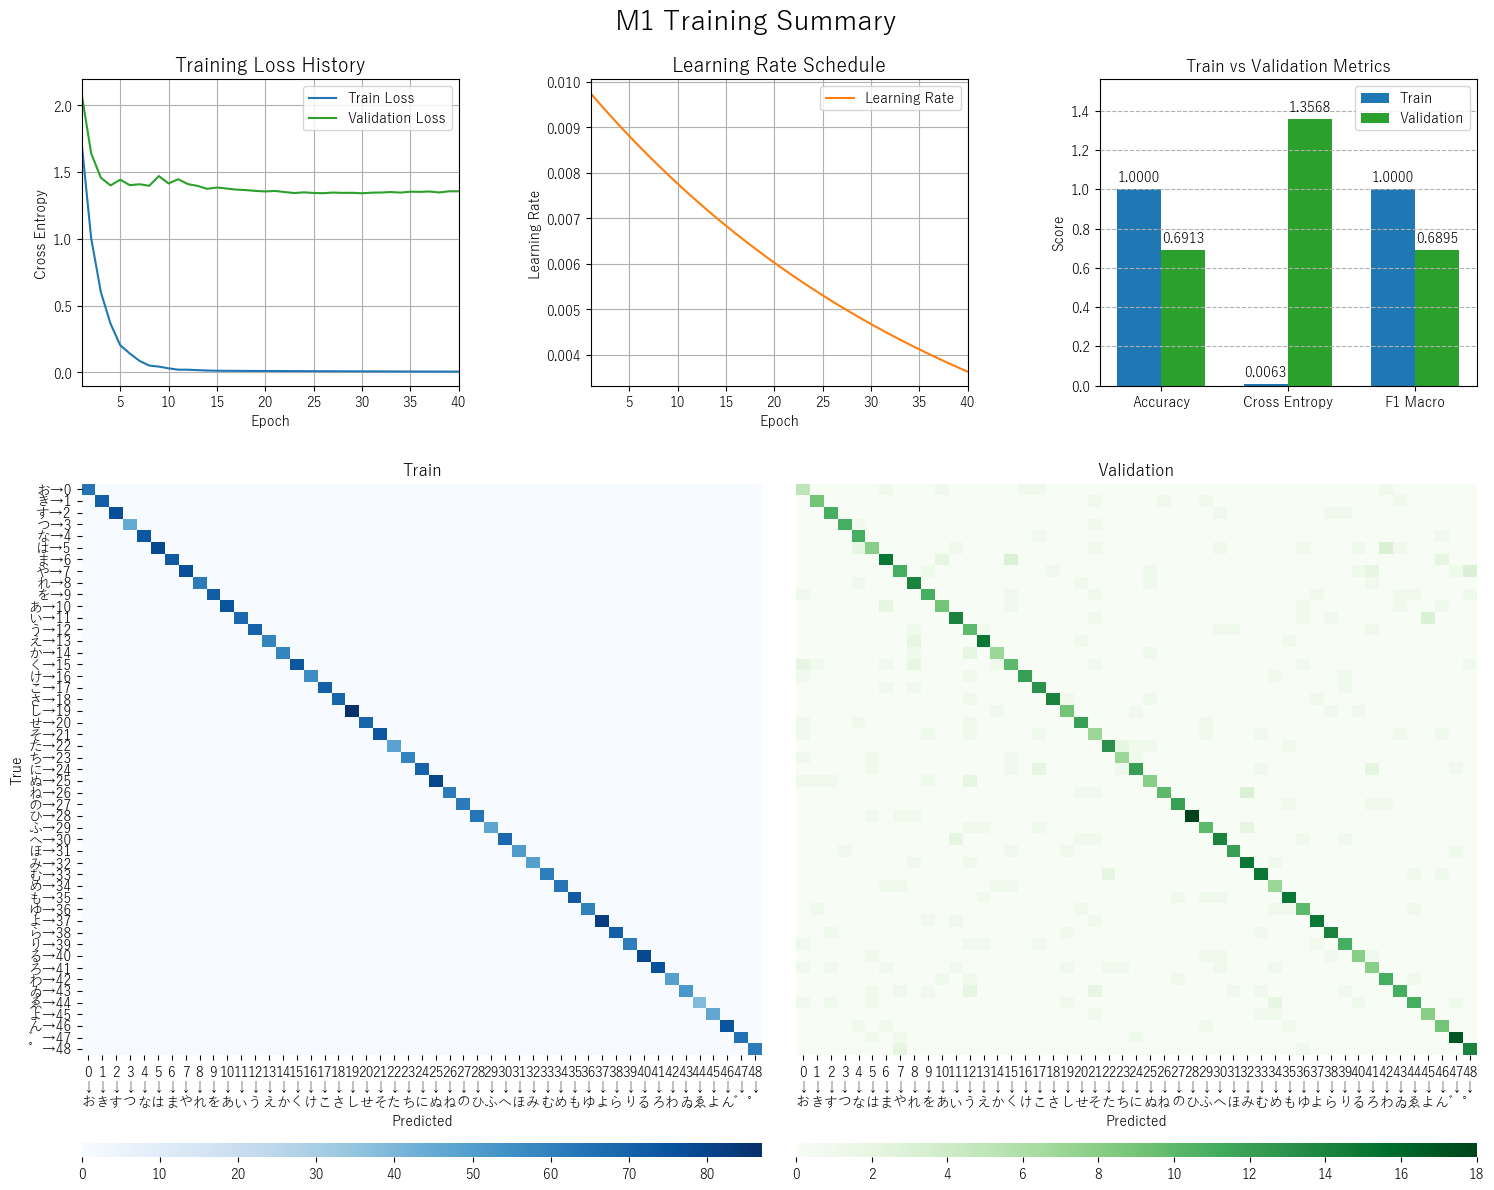

In [ ]:
training_summary(M1, M1_train_hist, X_train, y_train, X_val, y_val, title='M1 Training Summary')

# Desarrollo de una Red Neuronal con **PyTorch**

## **Modelo** $\boldsymbol{M_2}$

Para este primer modelo realizado a partir de la libería de Deep Learning, **PyTorch**, se usarán los mismos hiperparámetros usados por el modelo anterior con el objetivo de comparar ambas implementaciones de redes neuronales a igualdad de condiciones (mismos datos de entrenamiento, validación e hiperparámetros). 

In [ ]:
M2_fit_params = M1_fit_params
M2 = TorchNN(
    input_size, output_size, 
    layers=M1_layers, optimizer=torch.optim.AdamW,
    optim_params=M1_optimizer_params
    )
M2_train_hist = M2.fit(X_train, y_train, X_val, y_val, **M2_fit_params)

Training:  42%|████▏     | 42/100 [00:01<00:01, 38.76epoch/s, train_loss=0.0053, val_loss=1.2681]

[early stopping] — epoch: 43 | train_loss: 0.0053 | val_loss: 1.2681 | time: 1.1s


Al observar el resumen de estadísticas de este nuevo modelo al ser entrenado confirmamos lo que uno esperaría, ambos modelos se presentan altamente similares hasta en las formas de sus curvas de funciones de costo a lo largo de las épocas de entrenamiento.

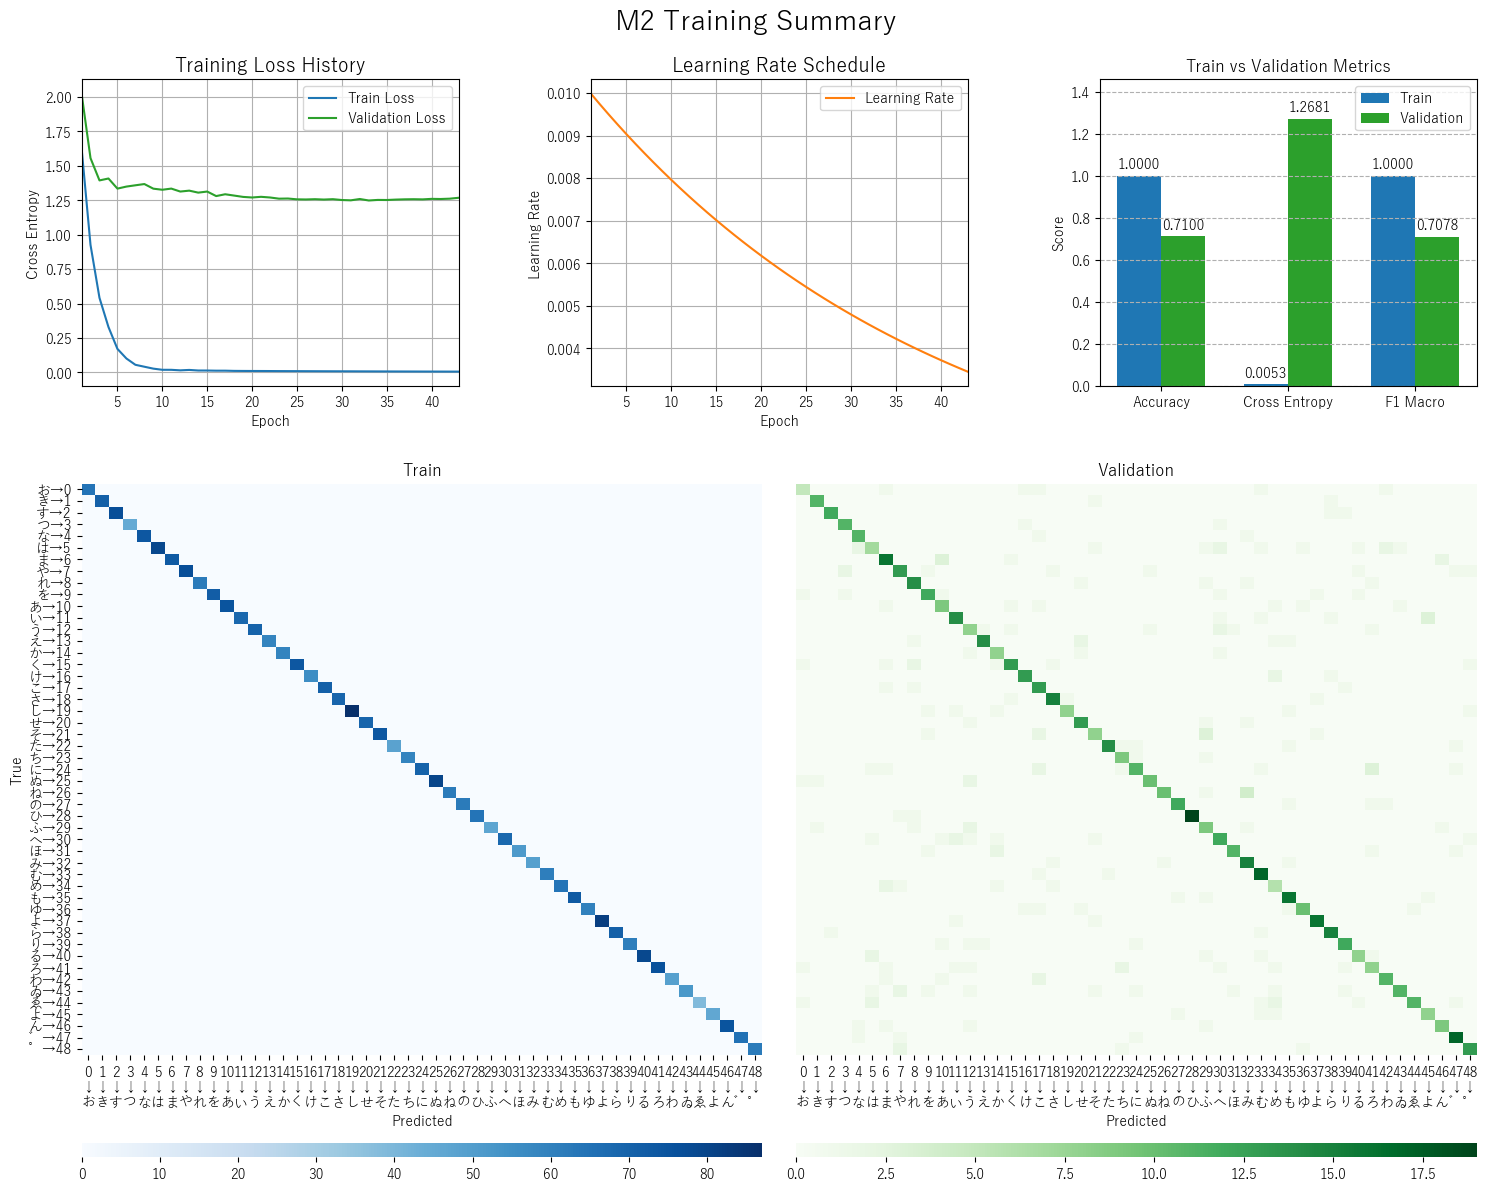

In [ ]:
training_summary(M2, M2_train_hist, X_train, y_train, X_val, y_val, title='M2 Training Summary')

Aunque la gran sorpresa se encuentra en las métricas donde se ve una diferencia positiva, aunque muy pequeña, respecto al modelo implementado *from scratch* en el trabajo, obteniendo tanto un accuracy como un f1-score alrededor del $0.71$. De todas formas esta pequeña diferencia puede variar simplemente re-entrenando el modelo con las mismos parámetros, simplemente con la inicialización de los parámetros de las redes puede influir en estas métricas. 

Esto último se puede observar en el gráfico de abajo, en el que se re-entrena a $M_2$ a igualdad de hiperparámetros, solo re-inicializando sus pesos en cada "run". Obtuvimos que tanto accuracy como f1-score macro conllevan un desvío estándar apoximadamente de $\pm 0.01$, por lo que la diferencia en métricas entre $M_1$ y $M_2$ podría ser simplemente obra de la inicialización de los pesos de ambos modelos.

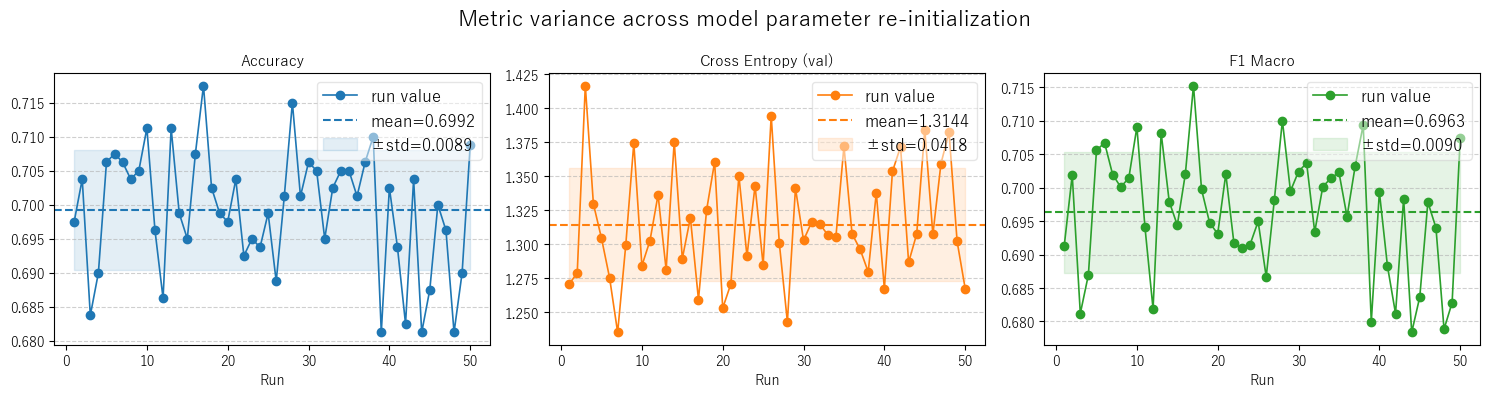

In [ ]:
records = initialization_variance(M2, M2_fit_params, X_train, y_train, X_val, y_val, n_runs=50)
initialization_variance_plot(records)

En la práctica esta diferencia de métrica es casi imperceptible pero aún así es un dato que sorprende dado que PyTorch contiene una amplia cantidad de optimizaciones sobre los modelos y mejoras de bajo nivel que nuestra propia clase `NN` no contiene y aún así ambos se comportan casi de forma idéntica. 

Si es de destacar que el modelo de PyTorch tiene un entrenamiento mucho más veloz siendo que en nuestro caso este consigue realizar un estimado de casi 40 épocas por segundo mientras que nuestro propio modelo solo alcanza una época y media por segundo. Esto se debe a optimizaciones varias nativas de PyTorch además de la utilización de CUDA y Tensores (en vez de arrays de numpy) que utilizan la gran capacidad de la GPU para realizar muchísimas operaciones matemáticas en paralelo.

In [ ]:
print(torch.cuda.is_available()) 

True


## **Modelo** $\boldsymbol{M_3}$

Aumentando un último nivel de complejidad, ahora este modelo (también instanciado a partir de la librería **PyTorch**) podrá además tendrá la posibilidad de utilizar diferentes funciones de acticación para cada una de sus capas ocultas. Las funciones de activación que usaremos son alternativas que se basan en ReLU:

#### **GELU** (*Gaussian Error Linear Unit*)

Pondera cada entrada por la probabilidad de que sea mayor que cero bajo una distribución normal estándar $\Phi(x)$,
produciendo una activación suave y no monótona:

$$
\text{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2}\left[1 + \text{erf}\!\left(\frac{x}{\sqrt{2}}\right)\right]
$$

#### **SiLU**

También llamada *Swish*, es el producto de la entrada por su propia sigmoide. Al igual que GELU es suave y no
monótona, pero de forma cerrada y computacionalmente más barata:

$$
\text{SiLU}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}
$$

#### **Leaky ReLU**

Extiende ReLU permitiendo un pequeño gradiente $\alpha$ para entradas negativas, evitando el problema de las *neuronas
muertas* (gradiente nulo para $x < 0$):

$$
\text{LeakyReLU}(x) = \begin{cases} x & x > 0 \\ \alpha\, x & x \leq 0 \end{cases}
$$

donde típicamente $\alpha = 0.01$.

Y además se agrega una nueva forma de regularizaición:

#### **Dropout**

Durante el entrenamiento, cada neurona de una capa se desactiva independientemente con probabilidad $p$, forzando a la red a no depender de ninguna neurona en particular:

$$
\tilde{z}_i^{(\ell)} = m_i^{(\ell)} \cdot z_i^{(\ell)}, \qquad m_i^{(\ell)} \sim \text{Bernoulli}(1-p)
$$

Para mantener la esperanza de la activación constante entre entrenamiento e inferencia, las activaciones que
sobreviven se reescalan por $\frac{1}{1-p}$ (*inverted dropout*). En inferencia se desactiva el dropout y se usan
todas las neuronas sin reescalado.

El efecto regularizador surge porque al eliminar neuronas aleatoriamente en cada paso, el modelo no puede
co-adaptarse: cada neurona debe aprender representaciones útiles de forma independiente, lo que equivale a entrenar un
ensamble implícito de $2^n$ subredes distintas.

Al igual que realizamos para $M_1$, aplicaremos un grid-search a partir de una grilla de parámetros actualizada con arquitecturas de variadas funciones de activación y también ajustando el nuevo parámetro de regularización (dropout).

In [ ]:
M3_param_grid = {
    'layers' : [
        [(512, 'silu')],
        [(512, 'gelu')],
        [(512, 'leaky_relu')],
        [(1024, 'silu')],
        [(1024, 'gelu')],
        [(1024, 'leaky_relu')],
        [(256, 'silu'), (64, 'gelu')],
        [(256, 'silu'), (64, 'leaky_relu')],
        [(512, 'gelu'), (64, 'silu')],
        [(512, 'leaky_relu'), (64, 'gelu')],
	],
    'dropout' : [0.1, 0.3, 0.5],
    'gamma' : [0.975, 0.96, 0.95, 0.9],
    'batch_size' : [258, 512]
}

M3_fit_params = M1_fit_params
M3_optim_param_grid = {'lr': [1e-2], 'weight_decay': [0.25, 0.2, 0.15, 0.1]}

M3_gs = grid_search(
    X_train, y_train, X_val, y_val, param_grid=M3_param_grid, fit_params=M3_fit_params, 
	model_class=TorchNN, optimizer_class=torch.optim.AdamW, optimizer_param_grid=M3_optim_param_grid
    )

GRID SEARCH [TorchNN / AdamW] — 960 models [layers(10) x dropout(3) x gamma(4) x batch_size(2) x lr(1) x weight_decay(4)]


[512→64]: 100%|██████████| 960/960 [08:29<00:00,  1.88model/s, best=1.1207, val_loss=2.9635]


In [ ]:
M3_gs.to_csv(indexed_path('results/grid-search-M3.csv'))

Una vez más observamos que los mejores modelos resultantes son aquellos de una capa oculta y gran cantidad de neuronas, y con altísimos niveles de regularización (dropout=5, weight_decay=0.25).

> [**Observación**] Siendo que los mejores modelos son aquellos que toman los mayores valores de regularización de la grilla, la buena práctica debería ser dar un dominio más amplio de estos para que el algoritmo encuentre los valores realmente óptimos. Aunque por una falta de tiempo nos conformaremos con estos.

In [ ]:
M3_gs.drop(columns=['layers']).head(15)

,layers_config,dropout,gamma,batch_size,lr,weight_decay,val_loss,val_f1_macro,epochs_trained
1,"[(1024, gelu)]",0.5,0.975,258,0.01,0.25,1.1207,0.7231,71
2,"[(1024, gelu)]",0.5,0.900,258,0.01,0.25,1.1452,0.7125,21
3,"[(1024, gelu)]",0.3,0.960,258,0.01,0.25,1.1473,0.7211,61
4,"[(1024, gelu)]",0.5,0.950,258,0.01,0.25,1.1495,0.7219,43
5,"[(1024, gelu)]",0.3,0.950,258,0.01,0.25,1.1519,0.7121,50
6,"[(1024, silu)]",0.5,0.960,258,0.01,0.25,1.1603,0.7251,50
7,"[(1024, silu)]",0.5,0.900,258,0.01,0.20,1.1670,0.7018,24
8,"[(1024, gelu)]",0.5,0.960,258,0.01,0.20,1.1706,0.7291,79
9,"[(1024, leaky_relu)]",0.5,0.900,258,0.01,0.20,1.1722,0.7072,26
10,"[(1024, gelu)]",0.3,0.950,258,0.01,0.20,1.1736,0.7216,43


Finalmente la configuración de hiperparámetros y estructura de $M_3$ es:

In [ ]:
M3_config = M3_gs.iloc[0] 
M3_layers = M3_config['layers_config']
M3_fit_params.update({'batch_size' : M3_config['batch_size'], 'gamma' : M3_config['gamma']})
M3_optimizer_params = {'lr' : M3_config['lr'], 'weight_decay' : M3_config['weight_decay']}
print('M3 Layers', M3_layers)
print('M3 Fit Params')
pprint({**M3_fit_params, **M3_optimizer_params}, indent=2)

M3 Layers [(1024, 'gelu')]
M3 Fit Params
{ 'batch_size': np.int64(258),
  'epochs': 100,
  'gamma': np.float64(0.975),
  'lr': np.float64(0.01),
  'lr_schedule': 'exponential',
  'patience': 10,
  'weight_decay': np.float64(0.25)}


In [ ]:
M3 = TorchNN(input_size, output_size, layers=M3_layers, dropout=M3_config['dropout'],
             optimizer=torch.optim.AdamW, optim_params=M3_optimizer_params)
M3_train_hist = M3.fit(X_train, y_train, X_val, y_val, **M3_fit_params) 

Training:  15%|█▌        | 15/100 [00:00<00:01, 43.92epoch/s, train_loss=0.0260, val_loss=1.2635]

[early stopping] — epoch: 16 | train_loss: 0.0260 | val_loss: 1.2635 | time: 0.3s


Este modelo resulta también muy similar, obteniendo métricas casi idénticas a los dos modelos anteriores para el conjunto de validación. La gran diferencia en este es en la notable regularización, que se observa en la curva de la loss de entrenamiento que tiene una mayor dificultad para llegar al 0. Esto podría llevar al modelo a lograr una mejor generalización.

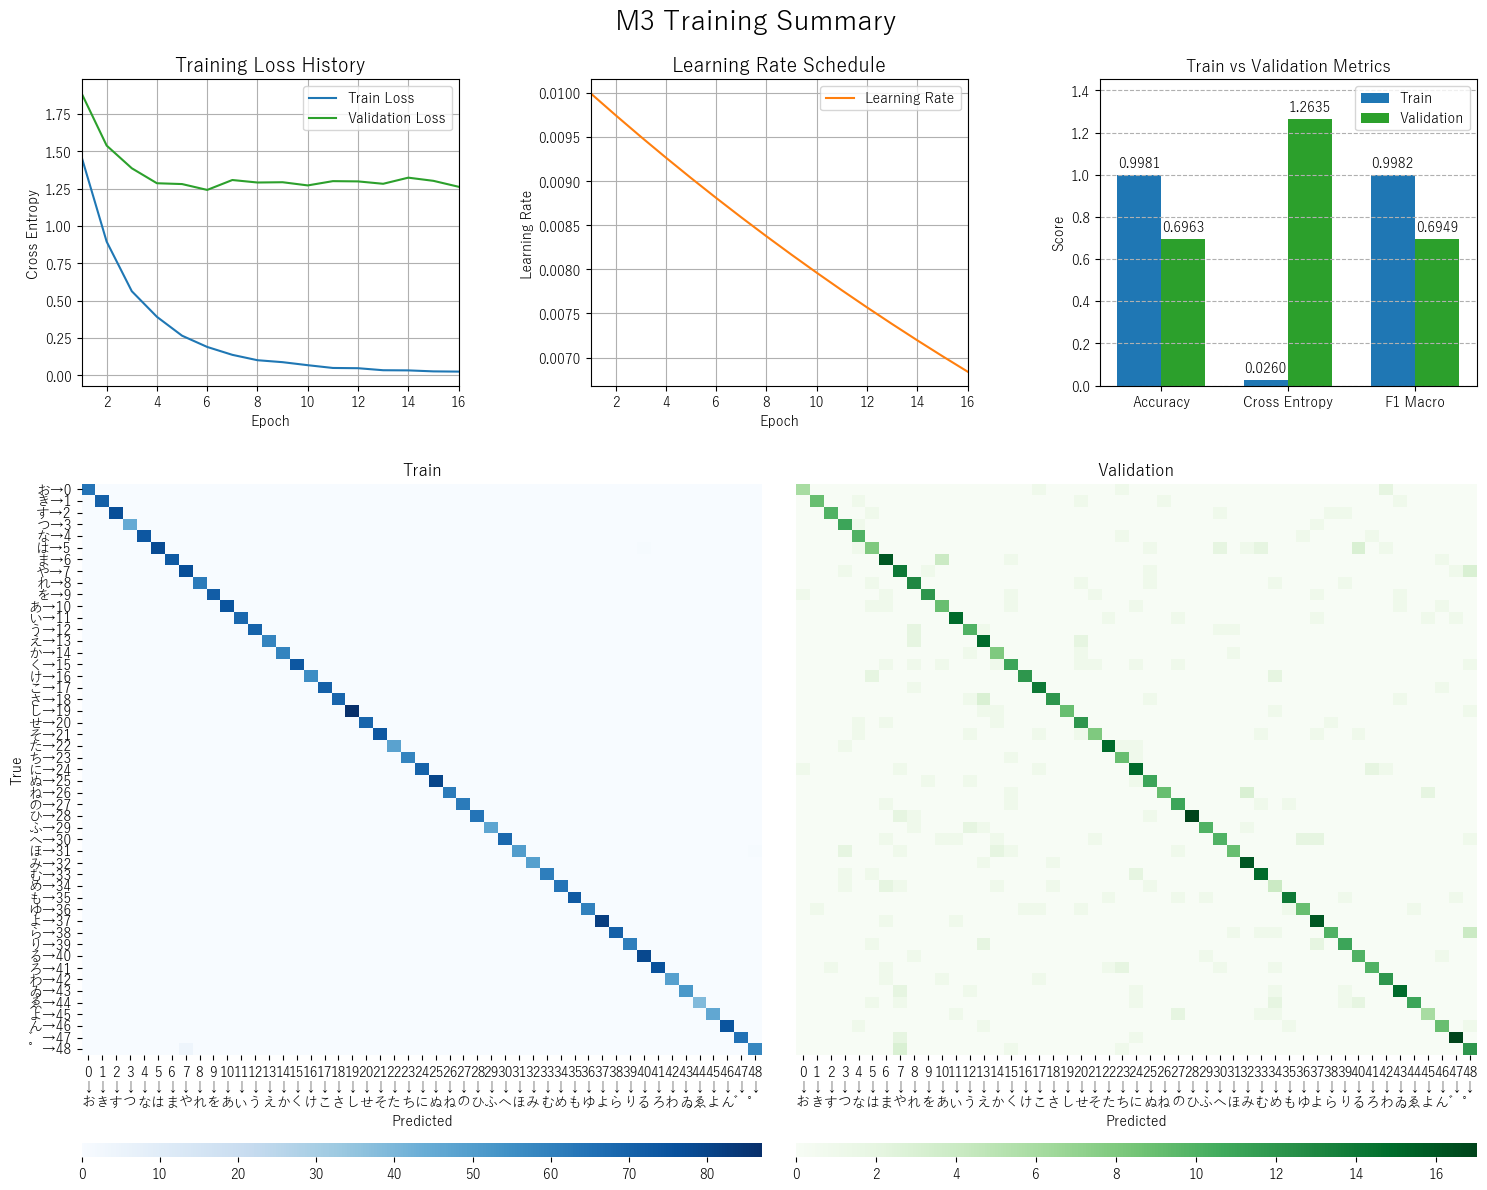

In [ ]:
training_summary(M3, M3_train_hist, X_train, y_train, X_val, y_val, title='M3 Training Summary')

### **Comparativa Final** de los Modelos

Como última fase de este trabajo, se re-entrenarán cada uno de los modelos definidos con todos los datos de desarrollo para luego compararlos con datos nunca antes vistos, el conjunto de prueba.

In [ ]:
models = [M0, M1, M2, M3]
fit_params_list = [M0_fit_params, M1_fit_params, M2_fit_params, M3_fit_params]
results = []
for model, fit_params in zip(models, fit_params_list):
	model._param_init()
	if hasattr(model.optimizer, 'setup'):
		model.optimizer.setup(model.weights, model.biases)
	result = model.fit(X_dev, y_dev, X_test, y_test, **fit_params)
	results.append(result)

Training: 100%|██████████| 400/400 [00:34<00:00, 11.51epoch/s, train_loss=0.8483, val_loss=1.6957]


[completed] — epoch: 400 | train_loss: 0.8483 | val_loss: 1.6957 | time: 34.8s


Training:  37%|███▋      | 37/100 [00:28<00:49,  1.28epoch/s, train_loss=0.0056, val_loss=1.3503]


[early stopping] — epoch: 38 | train_loss: 0.0056 | val_loss: 1.3503 | time: 28.9s


Training:  13%|█▎        | 13/100 [00:00<00:03, 23.52epoch/s, train_loss=0.0127, val_loss=1.3568]


[early stopping] — epoch: 14 | train_loss: 0.0127 | val_loss: 1.3568 | time: 0.6s


Training:  26%|██▌       | 26/100 [00:00<00:01, 41.86epoch/s, train_loss=0.0119, val_loss=1.2625]

[early stopping] — epoch: 27 | train_loss: 0.0119 | val_loss: 1.2625 | time: 0.6s


En la celda inferior se ubica la figura de la comparativa final de los modelos una vez entrenados con todos las muestras de desarrollo (*dev set*). Observamos la gran diferencia en el entrenamiento de $M_0$ con el resto, el cual en 400 épocas no llega a los resultados obtenidos por los modelos avanzados.

En términos de métricas (calculadas a partir de los datos del *test set*) observamos los ya vimos anteriormente. $M_0$ se presenta como un modelo con menor capacidad predictiva respecto a los demás, y tanto $M_1$, $M_2$ y $M_3$ tienen desempeños muy similares, aunque $M_3$ se posiciona como el mejor modelo hasta ahora. Además como vimos en este trabajo el mayor problema es el overfitting, por lo que $M_3$ tiene mayores chances de convertirse en un mejor modelo predictor si se le aplican más intensamente sus medidas de regularización.

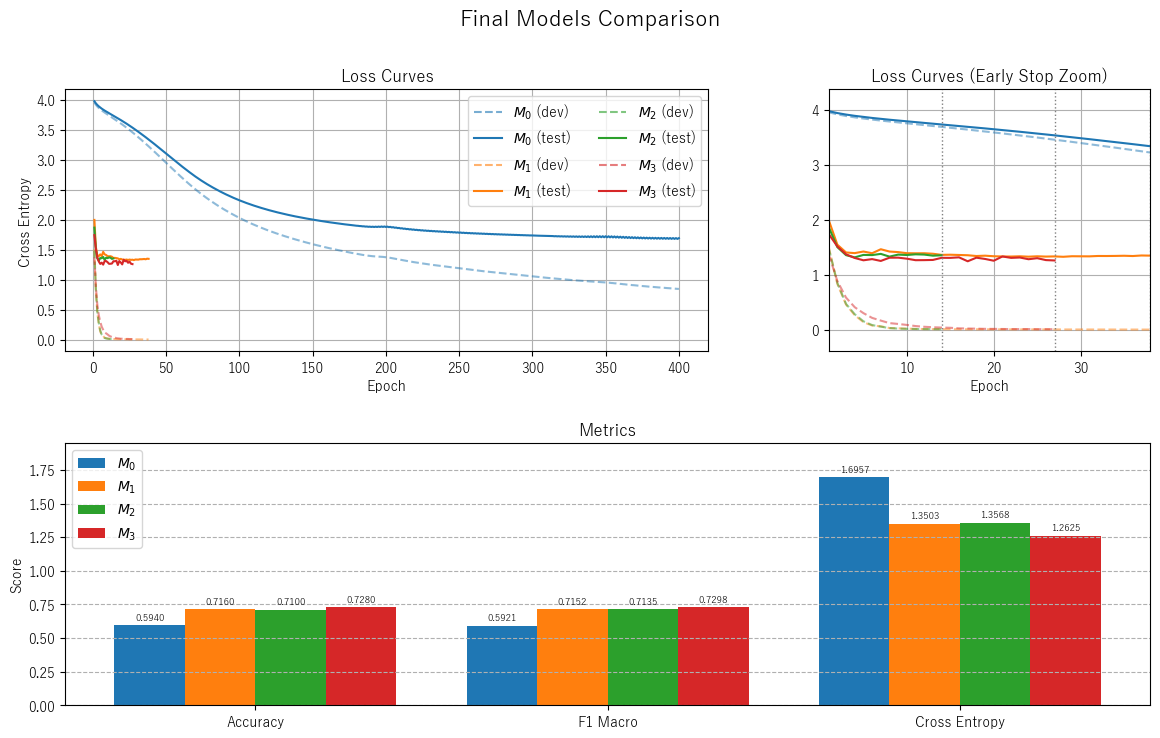

In [ ]:
compare_final_models(models, results, names=['$M_0$', '$M_1$', '$M_2$', '$M_3$'], X=X_test, y=y_test)

### **Análisis de Robustez** de los Modelos

Aplicando un ruido gaussiano $\epsilon \sim \mathcal{N}(0,\sigma^2)$ a las imágenes del conjunto de prueba se probará las reacciones de los modelo frente a perturbaciones en los datos. Se realizarán diferentes pruebas para múltiples niveles de ruido $\{\epsilon_i \sim \mathcal{N}(0,\sigma_i^2)\}_{i=1}^k$ y se analizará el desempeño de cada uno de los modelos en cada una de las pruebas. 

A continuación una demostración de como se visualizan una muestra del dataset ante los diferentes niveles de perturbaciones:

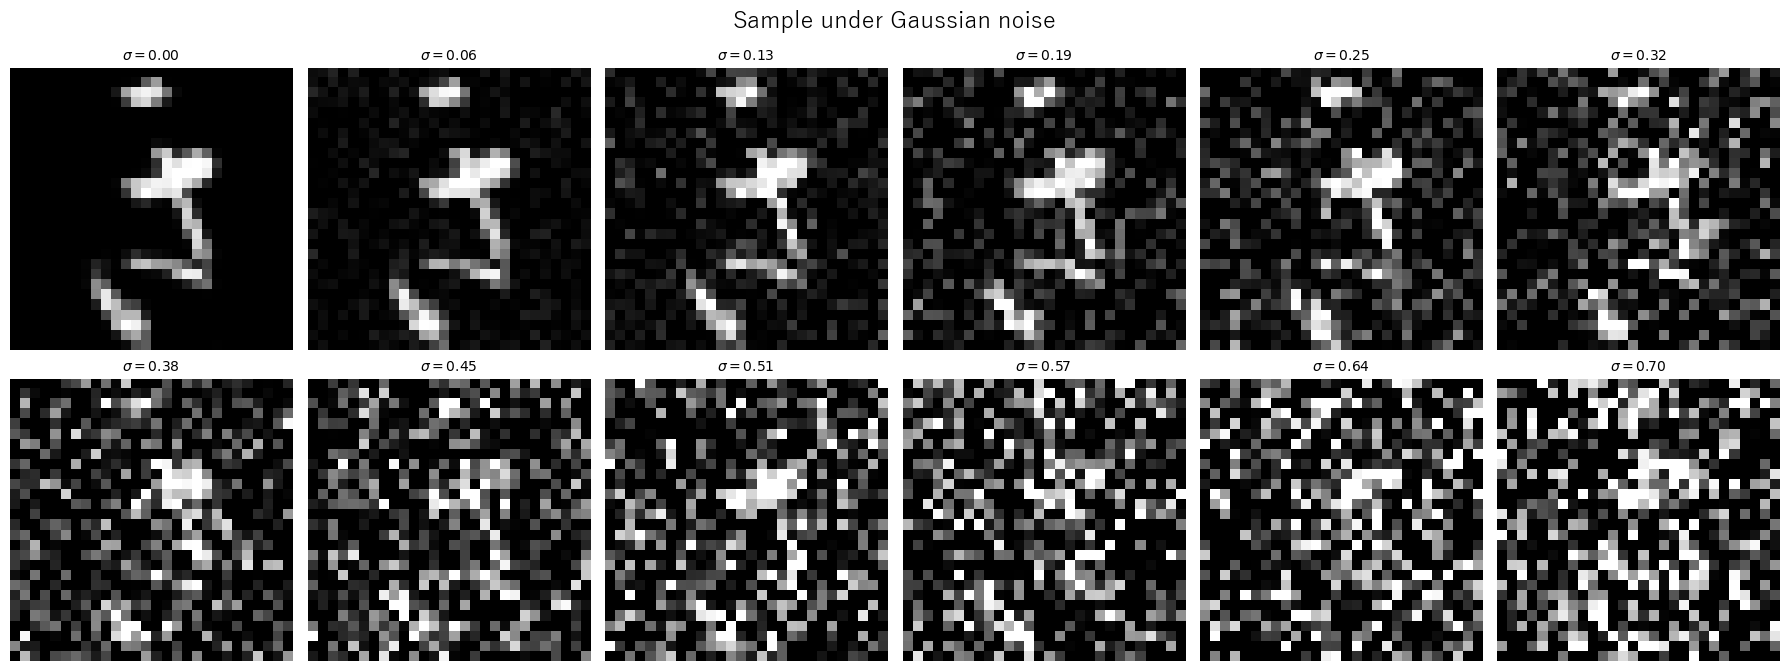

In [ ]:
noise_levels = np.linspace(start=0.0, stop=0.7, num=12, dtype=float)
show_noise_levels(X, noise_levels)

Podríamos decir que en general hasta un valor de $\sigma=0.25$ la persona promedio podría identificar con cierta dificultad el caracter, pero aumentando a partir de este punto ya es muy poco identificable.

Observando los resultados de las pruebas para las métricas de Accuracy y F1-Score (macro) en principio podemos destacar que los modelos $M_3$ y $M_1$ consiguen la misma performance para datos con perturbaciones de $\sigma \in [0.2, 0.3]$ que $M_0$ para datos sin alteraciones. Luego en tanto a la diferencia de performance individual es muy similar para todos los modelos, puesto que no hay ningún modelo que pareciera destacarse por su robustez ante estos cambios. Los modelos conservan su "ranking" de desempeño hasta $\sigma=0.4$, en donde todos comienzan a comportarse casi idénticamente.

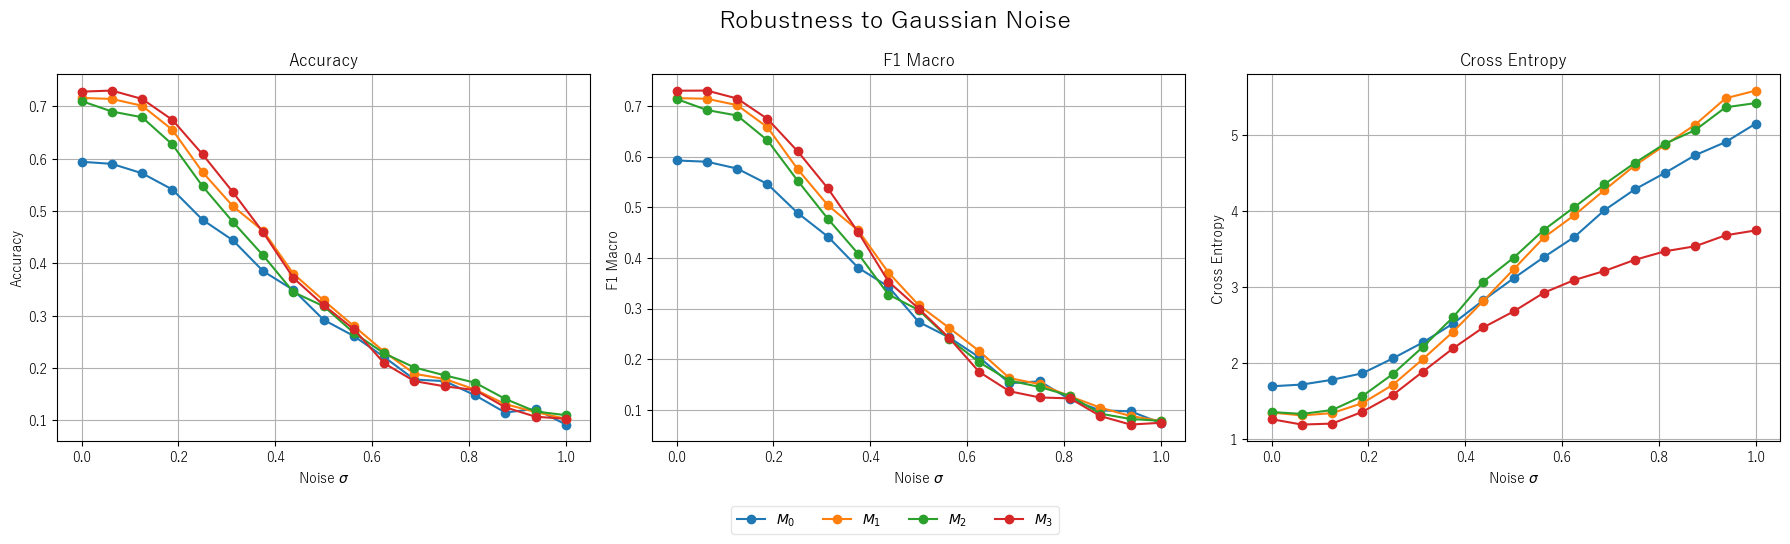

In [ ]:
noise_levels = np.linspace(start=0.0, stop=1.0, num=17, dtype=float)
names = ['$M_0$', '$M_1$', '$M_2$', '$M_3$']
robustness_df = robustness_test(models, names, X_test, y_test, noise_levels=noise_levels, n_classes=49)
robustness_plot(robustness_df)

$M_3$, a diferencia del resto de modelos, logra conservar una Entropía Cruzada menor a la de un modelo que predice las clases como uniformes como se explica en [esta celda](#loss_ceil). Mientras que todos los modelos alrededor de $\sigma \approx 0.65$ posicionan su entropía cruada por encima de este techo $(>\log(49)\approx0.389)$, $M_3$ es el único que la mantiene incluso un poco antes de $\sigma=1$ a un nivel inferior de este techo.